# Klasifikasi Jenis Serangan Jaringan IoT
## Menggunakan SVM, XGBoost, dan Random Forest

**Nama Mata Kuliah :** Pembelajaran Mesin  
**Kelas             :** A Informatika  
**Dataset           :** Heart Disease Prediction  — Kaggle  
**Link Dataset      :** https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction  
**Jumlah Data       :** 5.568 baris × 19 kolom

---

## 1. Import Library

In [ ]:
!pip install xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

print('✅ Semua library berhasil diimport!')
print(f'   Numpy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Semua library berhasil diimport!
   Numpy  : 2.0.2
   Pandas : 2.2.2


---
## 2. Data Understanding
### 2.1 Load Dataset

In [ ]:
# ============================================================
# OPSI A: Upload file CSV (Google Colab) — DISARANKAN
# ============================================================
from google.colab import files
uploaded = files.upload()                          # pilih heart_disease_prediction.csv
df = pd.read_csv(list(uploaded.keys())[0])

# ============================================================
# OPSI B: Jika file sudah ada di direktori yang sama
# ============================================================
# df = pd.read_csv('heart_disease_prediction.csv')

print(f'✅ Dataset berhasil dimuat!')
print(f'   Shape  : {df.shape[0]} baris × {df.shape[1]} kolom')
df.head(10)

Saving heart_disease_prediction.csv to heart_disease_prediction (2).csv
✅ Dataset berhasil dimuat!
   Shape  : 5568 baris × 19 kolom


,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol,heart_disease
0,1,0,66.0,2.0,4.0,2.0,0.82,0,0,0,0,0,0,1,0,1,1,0,0
1,1,1,66.0,2.0,6.0,1.0,1.63,0,0,0,0,0,0,0,0,1,1,1,0
2,1,0,75.0,2.0,4.0,4.0,0.41,0,0,1,1,0,0,1,1,1,1,0,0
3,0,0,56.0,1.0,6.0,5.0,5.00,0,0,0,0,1,0,0,0,1,0,1,0
4,0,0,67.0,1.0,3.0,3.0,2.65,0,0,0,0,0,0,1,1,1,0,0,0
5,0,0,54.0,2.0,4.0,4.0,1.86,1,0,0,0,0,1,1,0,0,0,1,0
6,0,1,71.0,1.0,7.0,3.0,1.56,0,0,0,0,1,0,1,1,1,0,1,1
7,0,0,61.0,1.0,6.0,5.0,5.00,0,0,0,0,0,0,1,0,1,0,0,0
8,0,0,22.0,1.0,3.0,3.0,1.49,0,0,0,0,1,0,1,1,0,0,0,0
9,1,0,45.0,1.0,4.0,3.0,1.18,0,0,0,0,1,0,0,0,1,1,0,0


### 2.2 Informasi Dataset

In [ ]:
print('=' * 65)
print('INFORMASI DATASET')
print('=' * 65)
print(f'Sumber  : Kaggle — Heart Disease Prediction')
print(f'Link    : https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction')
print(f'Baris   : {df.shape[0]}')
print(f'Kolom   : {df.shape[1]}')
print()
df.info()

INFORMASI DATASET
Sumber  : Kaggle — Heart Disease Prediction
Link    : https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction
Baris   : 5568
Kolom   : 19

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5568 entries, 0 to 5567
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   taking_bp_meds               5568 non-null   int64  
 1   taking_cholesterol_meds      5568 non-null   int64  
 2   age                          5568 non-null   float64
 3   sex                          5568 non-null   float64
 4   race_ethnicity               5568 non-null   float64
 5   education                    5568 non-null   float64
 6   poverty_income_ratio         5568 non-null   float64
 7   taking_insulin               5568 non-null   int64  
 8   taking_diabetes_pills        5568 non-null   int64  
 9   told_prediabetes             5568 non-null   int64  
 10  told_stroke     

In [ ]:
print('=' * 65)
print('DESKRIPSI FITUR / VARIABEL')
print('=' * 65)
feature_desc = {
    'taking_bp_meds'            : 'Sedang mengonsumsi obat tekanan darah (0=Tidak, 1=Ya)',
    'taking_cholesterol_meds'   : 'Sedang mengonsumsi obat kolesterol (0=Tidak, 1=Ya)',
    'age'                       : 'Usia pasien (tahun)',
    'sex'                       : 'Jenis kelamin (1=Laki-laki, 2=Perempuan)',
    'race_ethnicity'            : 'Ras/Etnis pasien (kode kategori)',
    'education'                 : 'Tingkat pendidikan (kode kategori)',
    'poverty_income_ratio'      : 'Rasio pendapatan terhadap garis kemiskinan',
    'taking_insulin'            : 'Sedang menggunakan insulin (0=Tidak, 1=Ya)',
    'taking_diabetes_pills'     : 'Mengonsumsi obat diabetes (0=Tidak, 1=Ya)',
    'told_prediabetes'          : 'Pernah didiagnosis prediabetes (0=Tidak, 1=Ya)',
    'told_stroke'               : 'Pernah didiagnosis stroke (0=Tidak, 1=Ya)',
    'family_history_heart_attack': 'Riwayat serangan jantung dalam keluarga (0=Tidak, 1=Ya)',
    'diabetes'                  : 'Terdiagnosis diabetes (0=Tidak, 1=Ya)',
    'smoking_ever'              : 'Pernah merokok (0=Tidak, 1=Ya)',
    'smoking_current'           : 'Saat ini merokok (0=Tidak, 1=Ya)',
    'physically_active'         : 'Aktif secara fisik (0=Tidak, 1=Ya)',
    'hypertension'              : 'Terdiagnosis hipertensi (0=Tidak, 1=Ya)',
    'high_cholesterol'          : 'Kolesterol tinggi (0=Tidak, 1=Ya)',
    'heart_disease'             : '🎯 TARGET — Penyakit jantung (0=Tidak, 1=Ya)'
}
for feat, desc in feature_desc.items():
    print(f'  {feat:35} : {desc}')

DESKRIPSI FITUR / VARIABEL
  taking_bp_meds                      : Sedang mengonsumsi obat tekanan darah (0=Tidak, 1=Ya)
  taking_cholesterol_meds             : Sedang mengonsumsi obat kolesterol (0=Tidak, 1=Ya)
  age                                 : Usia pasien (tahun)
  sex                                 : Jenis kelamin (1=Laki-laki, 2=Perempuan)
  race_ethnicity                      : Ras/Etnis pasien (kode kategori)
  education                           : Tingkat pendidikan (kode kategori)
  poverty_income_ratio                : Rasio pendapatan terhadap garis kemiskinan
  taking_insulin                      : Sedang menggunakan insulin (0=Tidak, 1=Ya)
  taking_diabetes_pills               : Mengonsumsi obat diabetes (0=Tidak, 1=Ya)
  told_prediabetes                    : Pernah didiagnosis prediabetes (0=Tidak, 1=Ya)
  told_stroke                         : Pernah didiagnosis stroke (0=Tidak, 1=Ya)
  family_history_heart_attack         : Riwayat serangan jantung dalam keluarga (0

In [ ]:
print('\n📊 STATISTIK DESKRIPTIF')
print('=' * 65)
df.describe().T


📊 STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
taking_bp_meds,5568.0,0.295977,0.456522,0.000000e+00,0.00,0.00,1.00,1.0
taking_cholesterol_meds,5568.0,0.215517,0.411218,0.000000e+00,0.00,0.00,0.00,1.0
age,5568.0,51.501796,17.813899,2.000000e+01,36.00,53.00,66.00,80.0
sex,5568.0,1.514907,0.499823,1.000000e+00,1.00,2.00,2.00,2.0
race_ethnicity,5568.0,3.509339,1.640247,1.000000e+00,3.00,3.00,4.00,7.0
education,5568.0,3.514907,1.214602,1.000000e+00,3.00,4.00,4.00,5.0
poverty_income_ratio,5568.0,2.496519,1.490829,5.397605e-79,1.35,2.14,3.65,5.0
taking_insulin,5568.0,0.043822,0.204717,0.000000e+00,0.00,0.00,0.00,1.0
taking_diabetes_pills,5568.0,0.128233,0.334379,0.000000e+00,0.00,0.00,0.00,1.0
told_prediabetes,5568.0,0.102550,0.303398,0.000000e+00,0.00,0.00,0.00,1.0


In [ ]:
print('📊 DISTRIBUSI KELAS TARGET (heart_disease)')
print('=' * 45)
counts = df['heart_disease'].value_counts()
pct    = df['heart_disease'].value_counts(normalize=True) * 100
print(f'  Kelas 0 (Tidak Sakit Jantung) : {counts[0]:>5} sampel  ({pct[0]:.2f}%)')
print(f'  Kelas 1 (Sakit Jantung)       : {counts[1]:>5} sampel  ({pct[1]:.2f}%)')
print(f'\n  ⚠️  Dataset TIDAK SEIMBANG — akan ditangani dengan SMOTE')

📊 DISTRIBUSI KELAS TARGET (heart_disease)
  Kelas 0 (Tidak Sakit Jantung) :  5041 sampel  (90.54%)
  Kelas 1 (Sakit Jantung)       :   527 sampel  (9.46%)

  ⚠️  Dataset TIDAK SEIMBANG — akan ditangani dengan SMOTE


---
## 3. Data Preprocessing
### 3.1 Cek Missing Values

In [ ]:
print('📋 CEK MISSING VALUES')
print('=' * 45)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

📋 CEK MISSING VALUES
                             Jumlah Missing  Persentase (%)
taking_bp_meds                            0             0.0
taking_cholesterol_meds                   0             0.0
age                                       0             0.0
sex                                       0             0.0
race_ethnicity                            0             0.0
education                                 0             0.0
poverty_income_ratio                      0             0.0
taking_insulin                            0             0.0
taking_diabetes_pills                     0             0.0
told_prediabetes                          0             0.0
told_stroke                               0             0.0
family_history_heart_attack               0             0.0
diabetes                                  0             0.0
smoking_ever                              0             0.0
smoking_current                           0             0.0
physically_active  

In [ ]:
# Imputasi missing values dengan median jika ada
cols_missing = df.columns[df.isnull().any()].tolist()
if cols_missing:
    for col in cols_missing:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f'  ✅ Kolom "{col}" diimputasi dengan median = {med}')
else:
    print('  ✅ Tidak ada missing values — tidak perlu imputasi.')
print(f'\n  Total missing setelah imputasi: {df.isnull().sum().sum()}')

  ✅ Tidak ada missing values — tidak perlu imputasi.

  Total missing setelah imputasi: 0


### 3.2 Penanganan Outlier (IQR Capping)

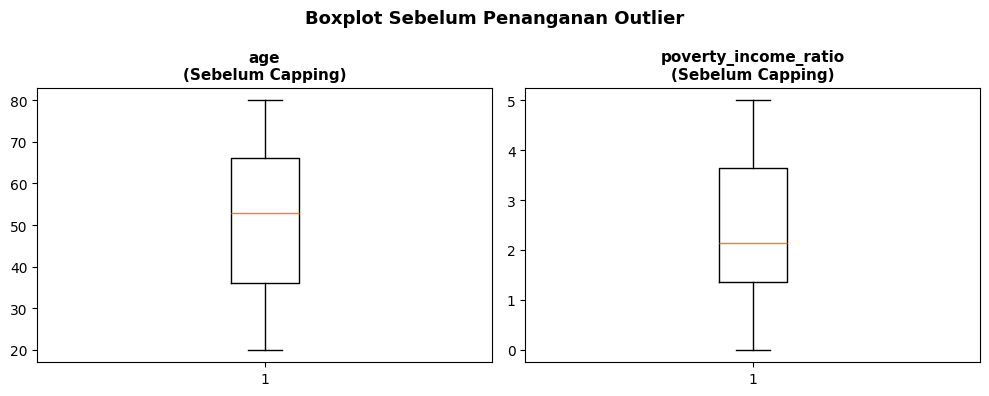

In [ ]:
# Hanya kolom kontinu yang perlu dicek outlier
continuous_cols = ['age', 'poverty_income_ratio']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}\n(Sebelum Capping)', fontsize=11, fontweight='bold')
plt.suptitle('Boxplot Sebelum Penanganan Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.copy()
outlier_report = []

for col in continuous_cols:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report.append({
        'Fitur': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'Lower Bound': round(lower,2), 'Upper Bound': round(upper,2),
        'Jumlah Outlier': n_out
    })
    df_clean[col] = df_clean[col].clip(lower, upper)

print('📊 LAPORAN OUTLIER (IQR Capping / Winsorization)')
print('=' * 70)
print(pd.DataFrame(outlier_report).to_string(index=False))
print(f'\nShape setelah penanganan outlier: {df_clean.shape}')

📊 LAPORAN OUTLIER (IQR Capping / Winsorization)
               Fitur    Q1    Q3  Lower Bound  Upper Bound  Jumlah Outlier
                 age 36.00 66.00         -9.0        111.0               0
poverty_income_ratio  1.35  3.65         -2.1          7.1               0

Shape setelah penanganan outlier: (5568, 19)


### 3.3 Pemisahan Fitur & Target

In [ ]:
X = df_clean.drop('heart_disease', axis=1)
y = df_clean['heart_disease']

print(f'Shape X (fitur)  : {X.shape}')
print(f'Shape y (target) : {y.shape}')
print(f'Fitur            : {X.columns.tolist()}')

Shape X (fitur)  : (5568, 18)
Shape y (target) : (5568,)
Fitur            : ['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex', 'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin', 'taking_diabetes_pills', 'told_prediabetes', 'told_stroke', 'family_history_heart_attack', 'diabetes', 'smoking_ever', 'smoking_current', 'physically_active', 'hypertension', 'high_cholesterol']


### 3.4 Normalisasi Data (StandardScaler)

In [ ]:
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('✅ Normalisasi StandardScaler selesai.')
print('\nStatistik setelah normalisasi (mean ≈ 0, std ≈ 1):')
X_scaled.describe().loc[['mean', 'std']].round(3)

✅ Normalisasi StandardScaler selesai.

Statistik setelah normalisasi (mean ≈ 0, std ≈ 1):


,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol
mean,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 3.5 Penanganan Imbalanced Data (SMOTE)

📊 DISTRIBUSI SEBELUM SMOTE
heart_disease
0    5041
1     527
Name: count, dtype: int64

📊 DISTRIBUSI SETELAH SMOTE
heart_disease
0    5041
1    5041
Name: count, dtype: int64

Shape setelah SMOTE: X=(10082, 18), y=(10082,)


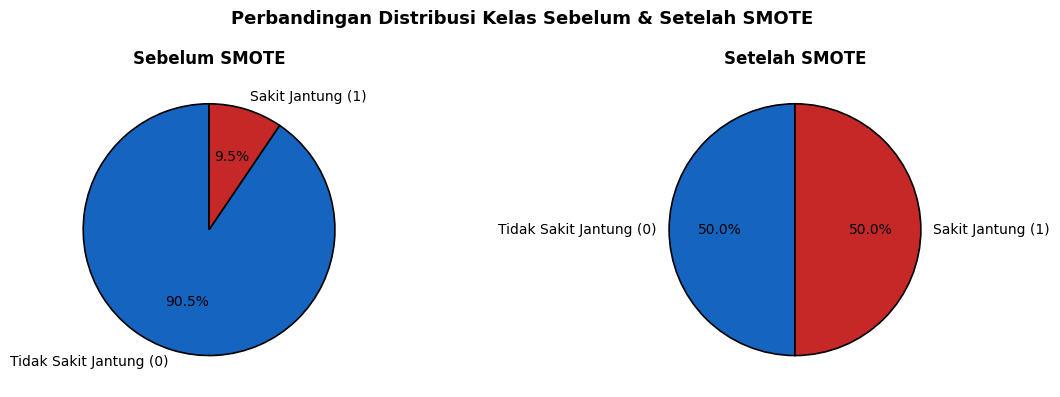

In [ ]:
print('📊 DISTRIBUSI SEBELUM SMOTE')
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print('\n📊 DISTRIBUSI SETELAH SMOTE')
print(pd.Series(y_resampled).value_counts())
print(f'\nShape setelah SMOTE: X={X_resampled.shape}, y={y_resampled.shape}')

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_names = ['Tidak Sakit Jantung (0)', 'Sakit Jantung (1)']
colors_pie  = ['#1565C0', '#C62828']

before = y.value_counts()
axes[0].pie(before.values, labels=label_names, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[0].set_title('Sebelum SMOTE', fontsize=12, fontweight='bold')

after = pd.Series(y_resampled).value_counts()
axes[1].pie(after.values, labels=label_names, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[1].set_title('Setelah SMOTE', fontsize=12, fontweight='bold')

plt.suptitle('Perbandingan Distribusi Kelas Sebelum & Setelah SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Exploratory Data Analysis (EDA)
### 4.1 Distribusi Seluruh Fitur

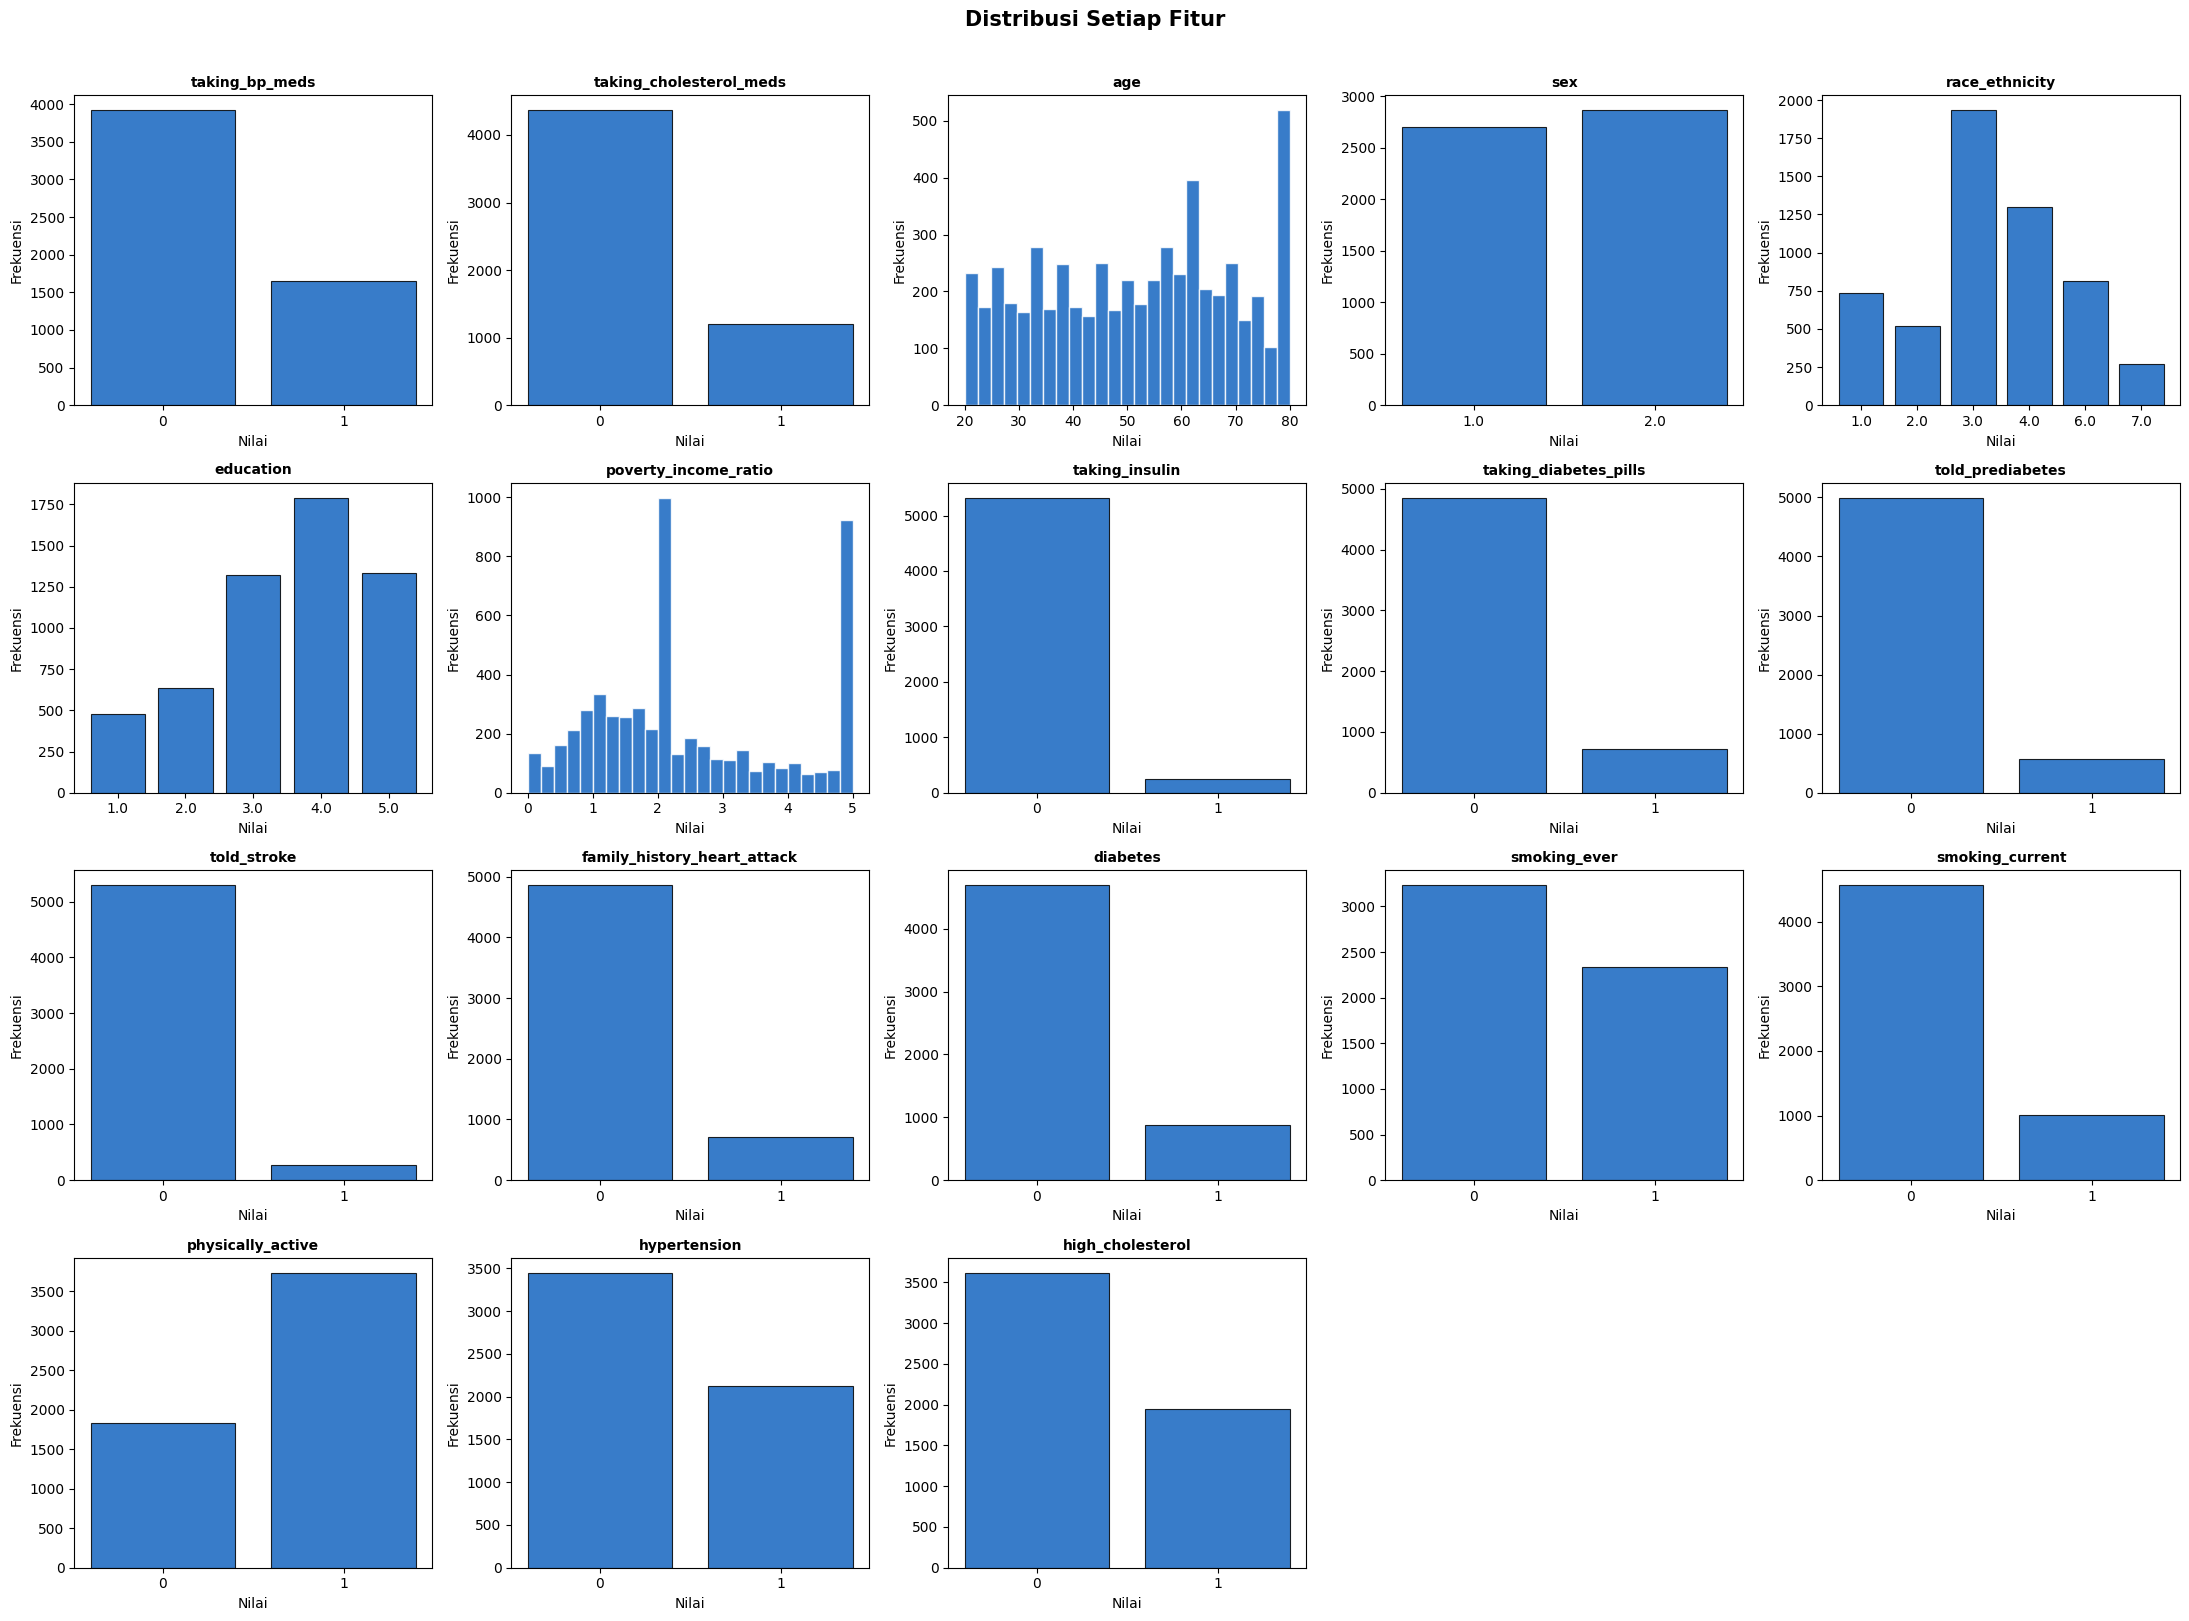

In [ ]:
all_feat_cols = X.columns.tolist()
n_cols = 5
n_rows = -(-len(all_feat_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(all_feat_cols):
    unique_vals = df_clean[col].nunique()
    if unique_vals <= 6:   # fitur biner / kategorikal
        vc = df_clean[col].value_counts().sort_index()
        axes[i].bar(vc.index.astype(str), vc.values,
                    color='#1565C0', edgecolor='black', linewidth=0.8, alpha=0.85)
        axes[i].set_ylabel('Frekuensi')
    else:                  # fitur kontinu
        axes[i].hist(df_clean[col], bins=25, color='#1565C0',
                     edgecolor='white', alpha=0.85)
        axes[i].set_ylabel('Frekuensi')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Distribusi Target

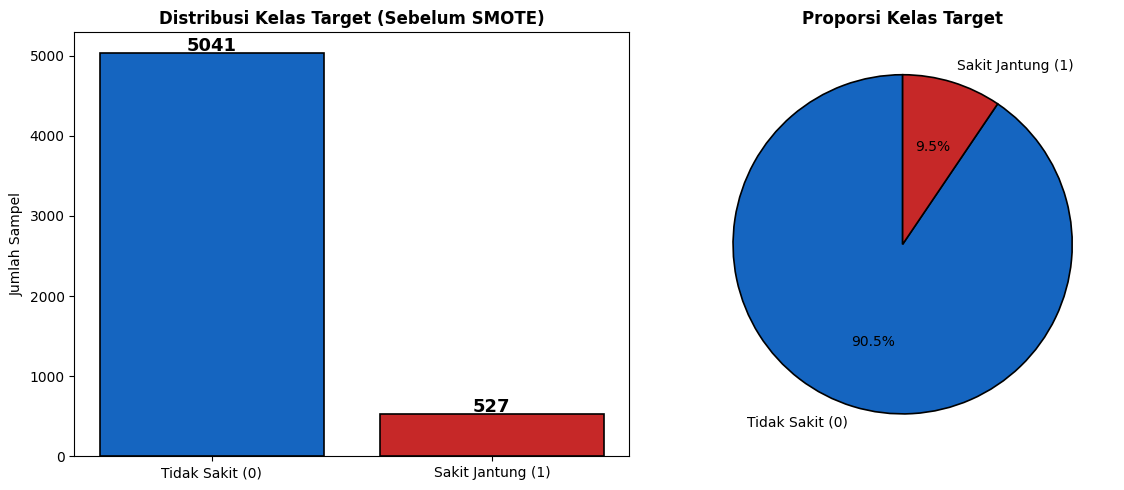

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = y.value_counts()

bars = axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'],
                   counts.values, color=['#1565C0', '#C62828'],
                   edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Distribusi Kelas Target (Sebelum SMOTE)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].pie(counts.values, labels=['Tidak Sakit (0)', 'Sakit Jantung (1)'],
            autopct='%1.1f%%', colors=['#1565C0', '#C62828'],
            startangle=90, wedgeprops={'edgecolor':'black','linewidth':1.2})
axes[1].set_title('Proporsi Kelas Target', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Heatmap Korelasi

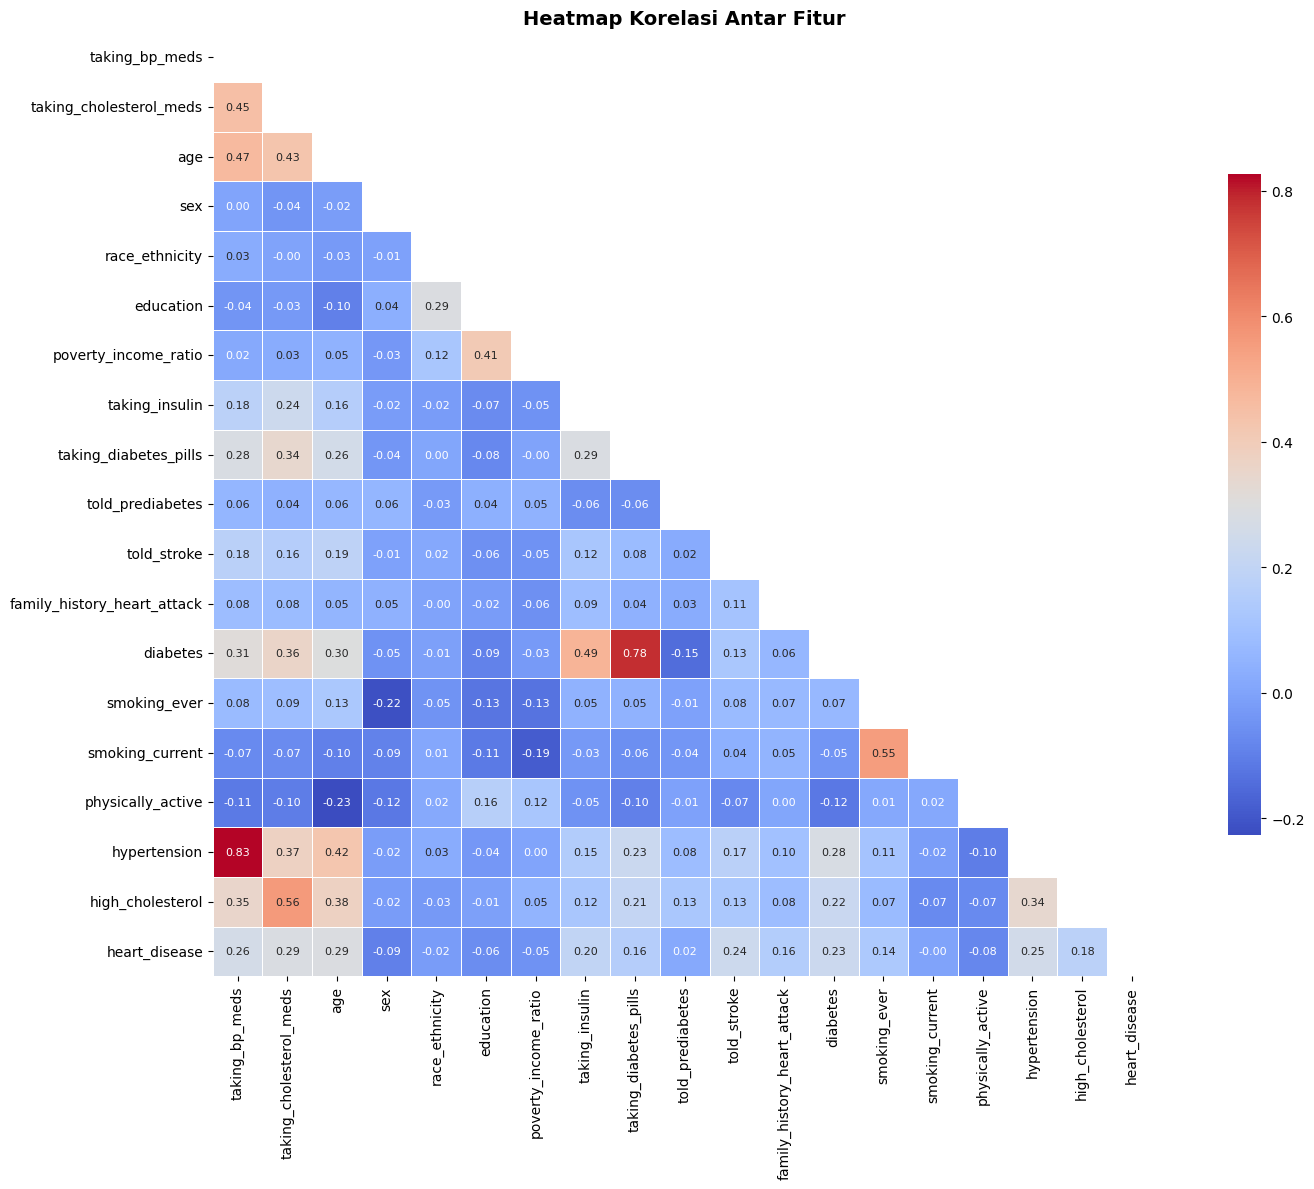

In [ ]:
plt.figure(figsize=(16, 12))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

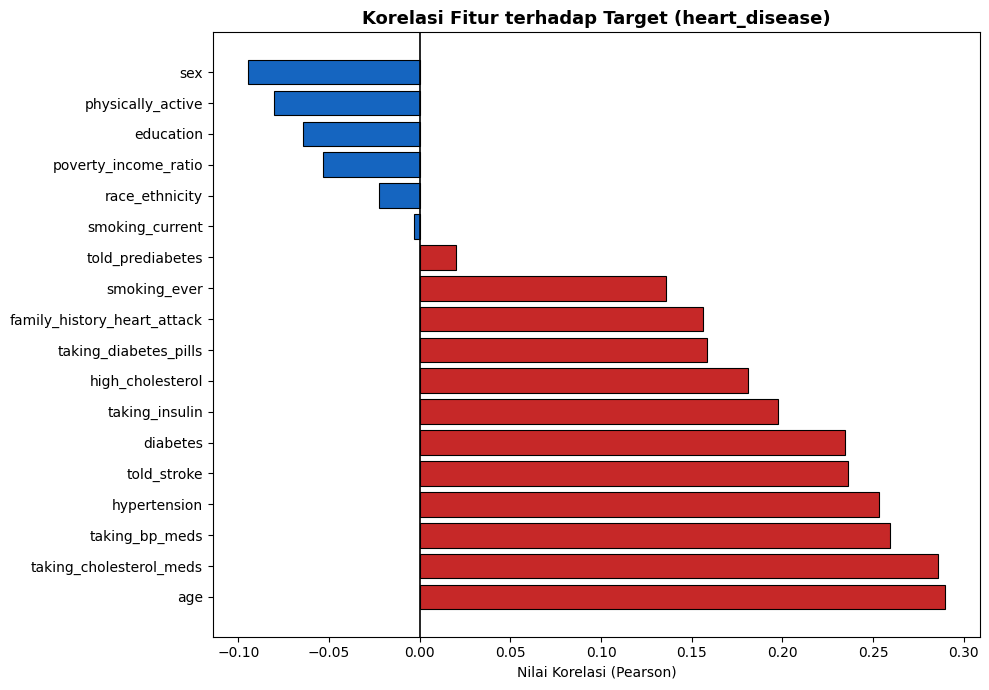

Top 5 fitur berkorelasi POSITIF dengan target:
age                        0.2897
taking_cholesterol_meds    0.2856
taking_bp_meds             0.2594
hypertension               0.2533
told_stroke                0.2363
Name: heart_disease, dtype: float64

Top 5 fitur berkorelasi NEGATIF dengan target:
race_ethnicity         -0.0222
poverty_income_ratio   -0.0533
education              -0.0643
physically_active      -0.0804
sex                    -0.0950
Name: heart_disease, dtype: float64


In [ ]:
target_corr = df_clean.corr()['heart_disease'].drop('heart_disease').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors_bar = ['#C62828' if v > 0 else '#1565C0' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values,
         color=colors_bar, edgecolor='black', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=1.2)
plt.title('Korelasi Fitur terhadap Target (heart_disease)',
          fontsize=13, fontweight='bold')
plt.xlabel('Nilai Korelasi (Pearson)')
plt.tight_layout()
plt.show()

print('Top 5 fitur berkorelasi POSITIF dengan target:')
print(target_corr.head(5).round(4))
print('\nTop 5 fitur berkorelasi NEGATIF dengan target:')
print(target_corr.tail(5).round(4))

### 4.4 Distribusi Fitur Penting per Kelas Target

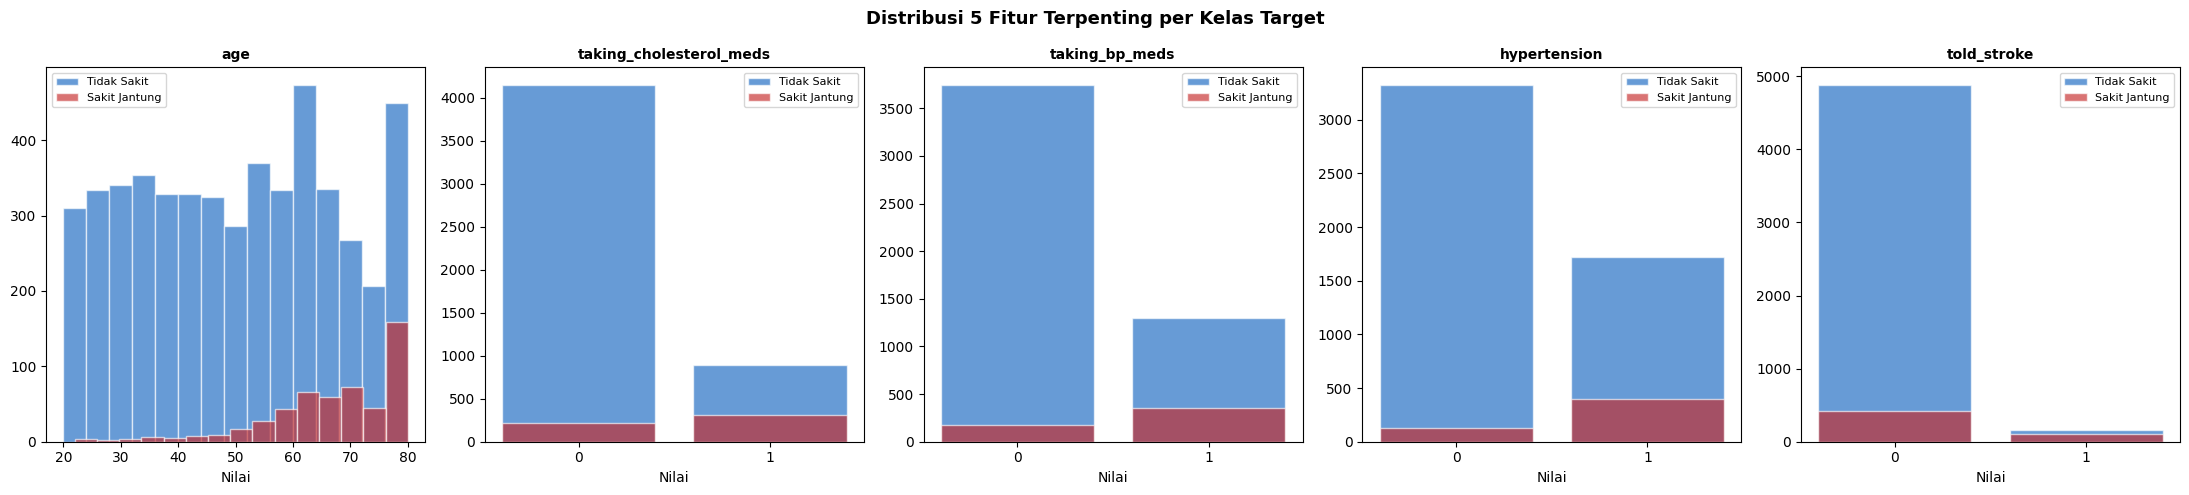

In [ ]:
top5 = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, feat in enumerate(top5):
    for cls, color, lbl in [(0, '#1565C0', 'Tidak Sakit'), (1, '#C62828', 'Sakit Jantung')]:
        data = df_clean[df_clean['heart_disease'] == cls][feat]
        if data.nunique() <= 6:
            vc = data.value_counts().sort_index()
            axes[i].bar([str(v) for v in vc.index], vc.values,
                        alpha=0.65, color=color, label=lbl, edgecolor='white')
        else:
            axes[i].hist(data, bins=15, alpha=0.65, color=color,
                         label=lbl, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Nilai')

plt.suptitle('Distribusi 5 Fitur Terpenting per Kelas Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Data Splitting
### 5.1 Tiga Kombinasi Rasio Split

In [ ]:
split_configs = [
    {'test_size': 0.30, 'label': '70:30 (Train:Test)'},
    {'test_size': 0.20, 'label': '80:20 (Train:Test)'},
    {'test_size': 0.10, 'label': '90:10 (Train:Test)'},
]

splits = []
print('=' * 60)
print('PEMBAGIAN DATA (Stratified Split dari data SMOTE)')
print('=' * 60)

for cfg in split_configs:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_resampled, y_resampled,
        test_size=cfg['test_size'],
        random_state=42,
        stratify=y_resampled
    )
    splits.append({
        'label'  : cfg['label'],
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te
    })
    print(f"\n{cfg['label']}")
    print(f'  Train : {len(X_tr):>5} sampel  |  Test : {len(X_te):>5} sampel')
    print(f'  Distribusi Train : {dict(pd.Series(y_tr).value_counts().sort_index())}')
    print(f'  Distribusi Test  : {dict(pd.Series(y_te).value_counts().sort_index())}')

PEMBAGIAN DATA (Stratified Split dari data SMOTE)

70:30 (Train:Test)
  Train :  7057 sampel  |  Test :  3025 sampel
  Distribusi Train : {0: np.int64(3528), 1: np.int64(3529)}
  Distribusi Test  : {0: np.int64(1513), 1: np.int64(1512)}

80:20 (Train:Test)
  Train :  8065 sampel  |  Test :  2017 sampel
  Distribusi Train : {0: np.int64(4032), 1: np.int64(4033)}
  Distribusi Test  : {0: np.int64(1009), 1: np.int64(1008)}

90:10 (Train:Test)
  Train :  9073 sampel  |  Test :  1009 sampel
  Distribusi Train : {0: np.int64(4536), 1: np.int64(4537)}
  Distribusi Test  : {0: np.int64(505), 1: np.int64(504)}


---
## 6. Hyperparameter Tuning (GridSearchCV — 5-Fold CV)
### 6.1 Tuning SVM

In [ ]:
# Basis tuning: split 80:20
X_train_tune = splits[1]['X_train']
y_train_tune = splits[1]['y_train']
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🔍 HYPERPARAMETER TUNING — SVM')
print('=' * 55)

svm_param_grid = {
    'C'     : [0.1, 1, 10, 50, 100],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto']
}

svm_gs = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_param_grid,
    cv=cv5, scoring='accuracy', n_jobs=-1, verbose=1
)
svm_gs.fit(X_train_tune, y_train_tune)

best_svm_params = svm_gs.best_params_
print(f'\n✅ Best Parameters SVM : {best_svm_params}')
print(f'✅ Best CV Accuracy SVM : {svm_gs.best_score_*100:.2f}%')

🔍 HYPERPARAMETER TUNING — SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best Parameters SVM : {'C': 50, 'gamma': 'auto', 'kernel': 'rbf'}
✅ Best CV Accuracy SVM : 93.11%


### 6.2 Tuning Random Forest

In [ ]:
print('🔍 HYPERPARAMETER TUNING — RANDOM FOREST')
print('=' * 55)

rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv5, scoring='accuracy', n_jobs=-1, verbose=1
)
rf_gs.fit(X_train_tune, y_train_tune)

best_rf_params = rf_gs.best_params_
print(f'\n✅ Best Parameters RF : {best_rf_params}')
print(f'✅ Best CV Accuracy RF : {rf_gs.best_score_*100:.2f}%')

🔍 HYPERPARAMETER TUNING — RANDOM FOREST
Fitting 5 folds for each of 96 candidates, totalling 480 fits

✅ Best Parameters RF : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best CV Accuracy RF : 94.31%


### 6.3 Tuning XGBoost

In [ ]:
print('🔍 HYPERPARAMETER TUNING — XGBOOST')
print('=' * 55)

xgb_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'gamma'            : [0, 0.1]
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    xgb_param_grid,
    cv=cv5, scoring='accuracy', n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train_tune, y_train_tune)

best_xgb_params = xgb_gs.best_params_
print(f'\n✅ Best Parameters XGB : {best_xgb_params}')
print(f'✅ Best CV Accuracy XGB : {xgb_gs.best_score_*100:.2f}%')

🔍 HYPERPARAMETER TUNING — XGBOOST
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best Parameters XGB : {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
✅ Best CV Accuracy XGB : 94.31%


### 6.4 Ringkasan Hasil Tuning

In [ ]:
print('=' * 65)
print('RINGKASAN HYPERPARAMETER TUNING')
print('=' * 65)
tuning_rows = [
    ('SVM',          svm_gs.best_score_,  best_svm_params),
    ('Random Forest', rf_gs.best_score_,  best_rf_params),
    ('XGBoost',      xgb_gs.best_score_, best_xgb_params),
]
for name, score, params in tuning_rows:
    print(f'\n  {name}')
    print(f'    CV Accuracy  : {score*100:.2f}%')
    print(f'    Best Params  : {params}')

RINGKASAN HYPERPARAMETER TUNING

  SVM
    CV Accuracy  : 93.11%
    Best Params  : {'C': 50, 'gamma': 'auto', 'kernel': 'rbf'}

  Random Forest
    CV Accuracy  : 94.31%
    Best Params  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

  XGBoost
    CV Accuracy  : 94.31%
    Best Params  : {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


---
## 7. Model Building & Evaluasi
### 7.1 Fungsi Evaluasi

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test,
                   model_name='', split_label=''):
    model.fit(X_train, y_train)

    # ── Prediksi di data TRAINING ──────────────────────────────
    y_pred_train = model.predict(X_train)
    acc_train  = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
    rec_train  = recall_score(y_train, y_pred_train, average='weighted', zero_division=0)
    f1_train   = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)

    # ── Prediksi di data TESTING ───────────────────────────────
    y_pred_test = model.predict(X_test)
    acc_test  = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    rec_test  = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    f1_test   = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

    return {
        'Model'    : model_name,
        'Split'    : split_label,
        # ── TEST metrics (dipakai evaluasi utama) ───────────────
        'Accuracy' : acc_test,
        'Precision': prec_test,
        'Recall'   : rec_test,
        'F1-Score' : f1_test,
        # ── TRAIN metrics (dipakai deteksi overfitting) ─────────
        'Acc_Train' : acc_train,
        'Prec_Train': prec_train,
        'Rec_Train' : rec_train,
        'F1_Train'  : f1_train,
        # ── Selisih Train - Test (gap overfitting) ──────────────
        'Gap_Acc'   : acc_train - acc_test,
        'Gap_F1'    : f1_train  - f1_test,
        # ── Lainnya ─────────────────────────────────────────────
        'CM'       : confusion_matrix(y_test, y_pred_test),
        'y_pred'   : y_pred_test,
        'model'    : model
    }

print('✅ Fungsi evaluate_model() diperbarui — sekarang menghitung')
print('   metrik di data TRAINING dan TESTING sekaligus.')

✅ Fungsi evaluate_model() diperbarui — sekarang menghitung
   metrik di data TRAINING dan TESTING sekaligus.


### 7.2 Training & Evaluasi pada 3 Split

In [ ]:
all_results = []

for split in splits:
    X_tr = split['X_train']
    X_te = split['X_test']
    y_tr = split['y_train']
    y_te = split['y_test']
    lbl  = split['label']

    print(f'\n{"="*68}')
    print(f'  SPLIT: {lbl}')
    print(f'{"="*68}')
    print(f'  {"Model":<16} {"Train Acc":>10} {"Test Acc":>10} {"Gap":>8}  {"Status"}')
    print(f'  {"-"*64}')

    # ── SVM ──────────────────────────────────────────────────────
    svm_model = SVC(**best_svm_params, random_state=42, probability=True)
    res_svm = evaluate_model(svm_model, X_tr, X_te, y_tr, y_te,
                              model_name='SVM', split_label=lbl)
    all_results.append(res_svm)
    gap_svm = res_svm['Gap_Acc']
    status_svm = '✅ Normal' if abs(gap_svm) <= 0.05 else ('⚠️ Overfitting' if gap_svm > 0.05 else '⚠️ Underfitting')
    print(f"  {'SVM':<16} {res_svm['Acc_Train']*100:>9.2f}% {res_svm['Accuracy']*100:>9.2f}% {gap_svm*100:>+7.2f}%  {status_svm}")

    # ── Random Forest ────────────────────────────────────────────
    rf_model = RandomForestClassifier(**best_rf_params, random_state=42)
    res_rf = evaluate_model(rf_model, X_tr, X_te, y_tr, y_te,
                             model_name='Random Forest', split_label=lbl)
    all_results.append(res_rf)
    gap_rf = res_rf['Gap_Acc']
    status_rf = '✅ Normal' if abs(gap_rf) <= 0.05 else ('⚠️ Overfitting' if gap_rf > 0.05 else '⚠️ Underfitting')
    print(f"  {'Random Forest':<16} {res_rf['Acc_Train']*100:>9.2f}% {res_rf['Accuracy']*100:>9.2f}% {gap_rf*100:>+7.2f}%  {status_rf}")

    # ── XGBoost ──────────────────────────────────────────────────
    xgb_model = XGBClassifier(**best_xgb_params, random_state=42,
                               eval_metric='logloss', use_label_encoder=False)
    res_xgb = evaluate_model(xgb_model, X_tr, X_te, y_tr, y_te,
                              model_name='XGBoost', split_label=lbl)
    all_results.append(res_xgb)
    gap_xgb = res_xgb['Gap_Acc']
    status_xgb = '✅ Normal' if abs(gap_xgb) <= 0.05 else ('⚠️ Overfitting' if gap_xgb > 0.05 else '⚠️ Underfitting')
    print(f"  {'XGBoost':<16} {res_xgb['Acc_Train']*100:>9.2f}% {res_xgb['Accuracy']*100:>9.2f}% {gap_xgb*100:>+7.2f}%  {status_xgb}")

print(f'\n  Keterangan Gap = Acc_Train − Acc_Test')
print(f'  |Gap| ≤ 5%  → ✅ Normal (tidak overfitting)')
print(f'  Gap   > 5%  → ⚠️ Overfitting (model terlalu hafal data latih)')
print(f'  Gap   < -5% → ⚠️ Underfitting (model kurang belajar)')


  SPLIT: 70:30 (Train:Test)
  Model             Train Acc   Test Acc      Gap  Status
  ----------------------------------------------------------------
  SVM                  97.93%     94.02%   +3.91%  ✅ Normal
  Random Forest        99.97%     94.98%   +5.00%  ✅ Normal
  XGBoost              97.70%     94.51%   +3.19%  ✅ Normal

  SPLIT: 80:20 (Train:Test)
  Model             Train Acc   Test Acc      Gap  Status
  ----------------------------------------------------------------
  SVM                  98.02%     93.95%   +4.06%  ✅ Normal
  Random Forest        99.98%     95.14%   +4.83%  ✅ Normal
  XGBoost              97.73%     94.50%   +3.23%  ✅ Normal

  SPLIT: 90:10 (Train:Test)
  Model             Train Acc   Test Acc      Gap  Status
  ----------------------------------------------------------------
  SVM                  98.05%     94.95%   +3.10%  ✅ Normal
  Random Forest        99.98%     95.54%   +4.44%  ✅ Normal
  XGBoost              97.51%     94.35%   +3.16%  ✅ Norma

### 7.3 Classification Report Lengkap (Split 80:20)

In [ ]:
res_8020  = [r for r in all_results if r['Split'] == '80:20 (Train:Test)']
X_te_ref  = splits[1]['X_test']
y_te_ref  = splits[1]['y_test']

for res in res_8020:
    print(f"\n{'='*60}")
    print(f"  Classification Report — {res['Model']} [Split 80:20]")
    print('='*60)
    y_p = res['model'].predict(X_te_ref)
    print(classification_report(y_te_ref, y_p,
                                 target_names=['Tidak Sakit Jantung','Sakit Jantung']))


  Classification Report — SVM [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.97      0.91      0.94      1009
      Sakit Jantung       0.91      0.97      0.94      1008

           accuracy                           0.94      2017
          macro avg       0.94      0.94      0.94      2017
       weighted avg       0.94      0.94      0.94      2017


  Classification Report — Random Forest [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.96      0.94      0.95      1009
      Sakit Jantung       0.95      0.96      0.95      1008

           accuracy                           0.95      2017
          macro avg       0.95      0.95      0.95      2017
       weighted avg       0.95      0.95      0.95      2017


  Classification Report — XGBoost [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.94      0.95      0.95 

### 7.4 Confusion Matrix (Semua Model & Semua Split)

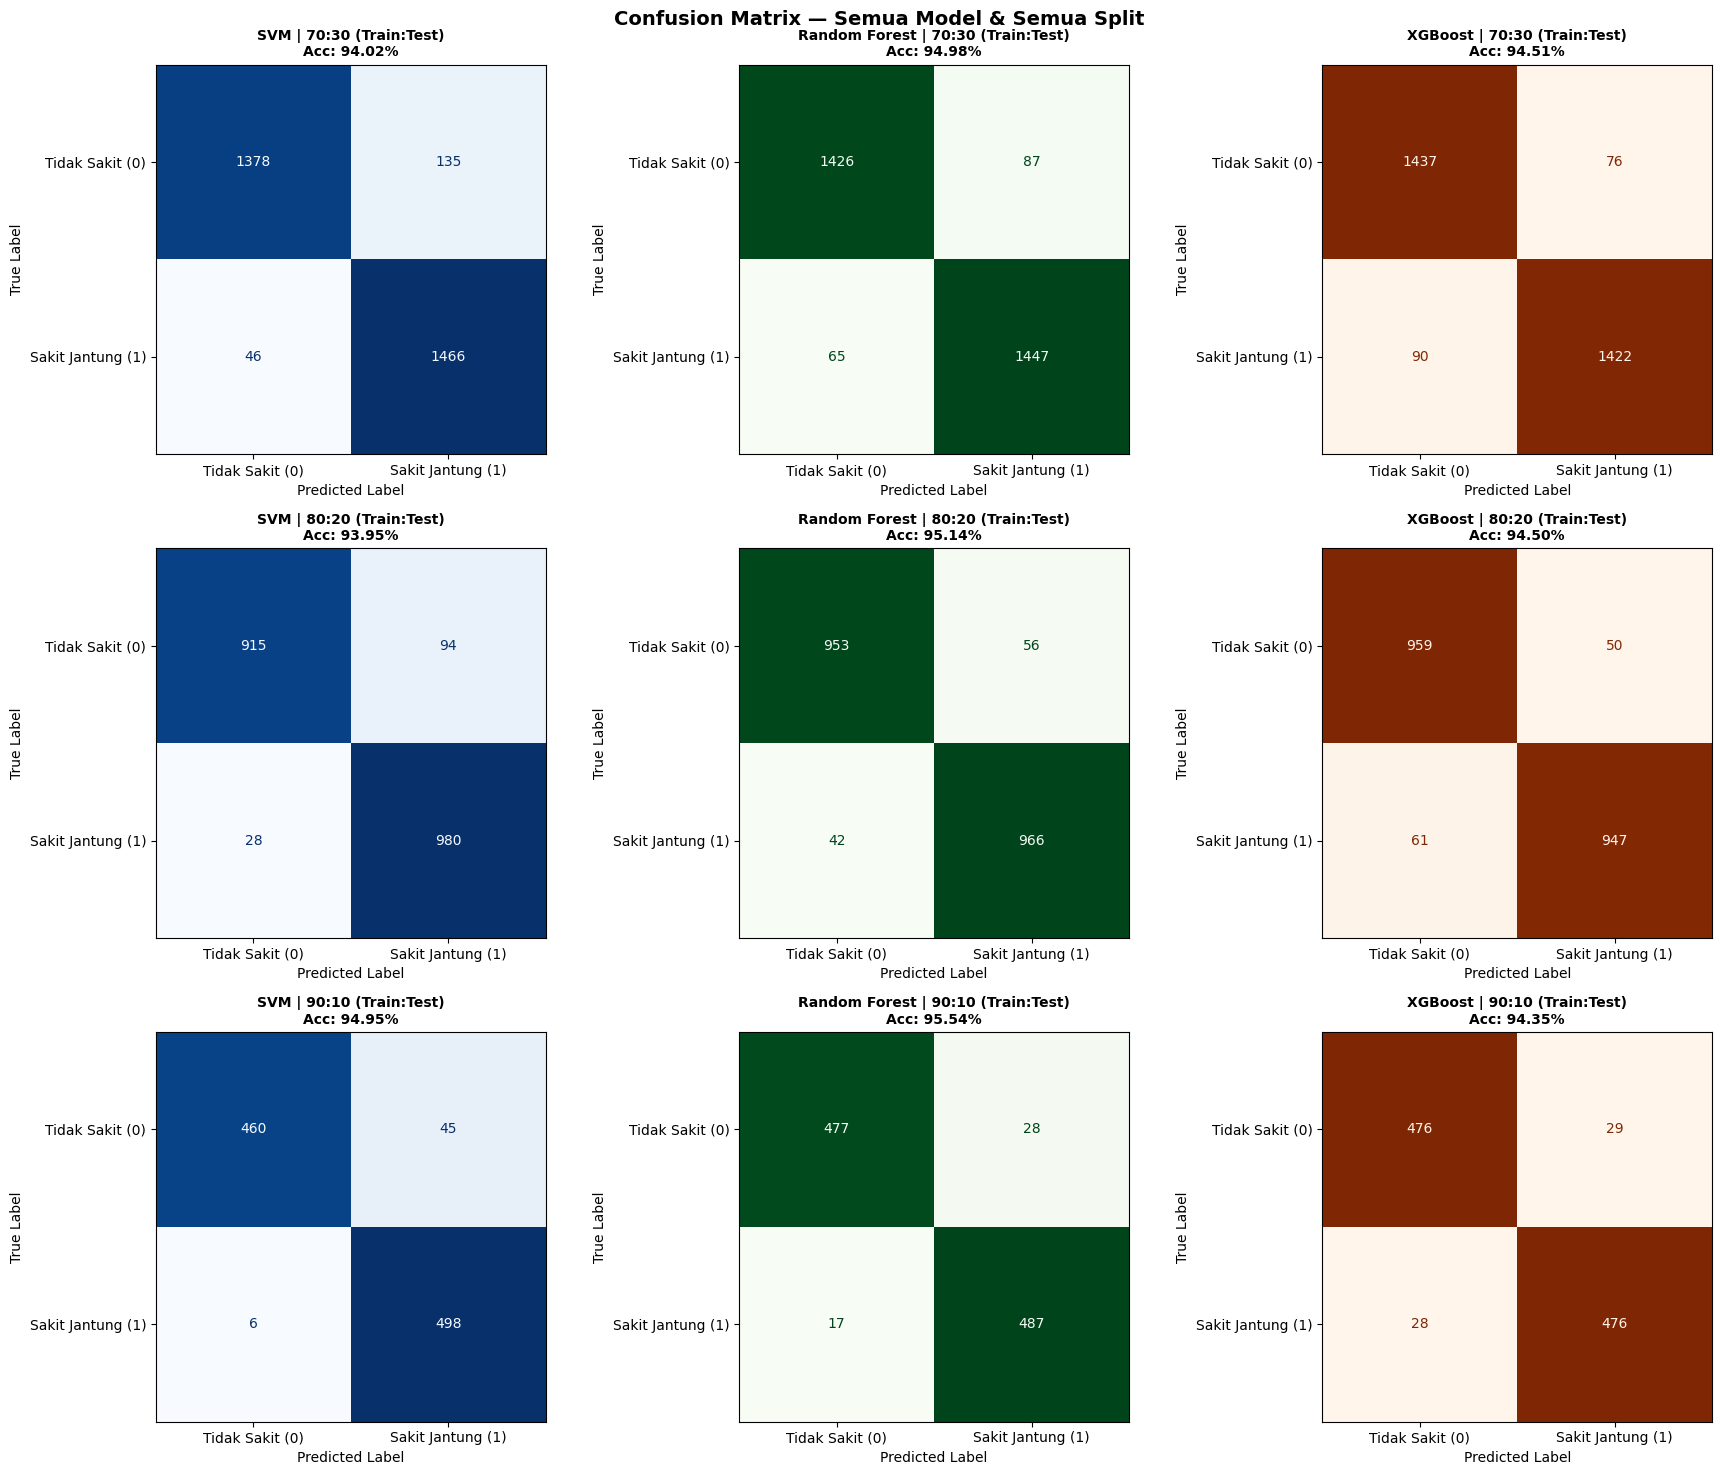

In [ ]:
class_names = ['Tidak Sakit (0)', 'Sakit Jantung (1)']
cmaps       = ['Blues', 'Greens', 'Oranges']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row_i, split in enumerate(splits):
    X_te_s  = split['X_test']
    y_te_s  = split['y_test']
    res_set = [r for r in all_results if r['Split'] == split['label']]
    for col_i, res in enumerate(res_set):
        cm   = confusion_matrix(y_te_s, res['model'].predict(X_te_s))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=axes[row_i][col_i], cmap=cmaps[col_i], colorbar=False)
        axes[row_i][col_i].set_title(
            f"{res['Model']} | {split['label']}\nAcc: {res['Accuracy']*100:.2f}%",
            fontsize=10, fontweight='bold')
        axes[row_i][col_i].set_xlabel('Predicted Label')
        axes[row_i][col_i].set_ylabel('True Label')

plt.suptitle('Confusion Matrix — Semua Model & Semua Split',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Analisis Overfitting — Train vs Test

In [ ]:
# ── Tabel lengkap Train vs Test semua model & split ───────────────────
rows_ov = []
for r in all_results:
    gap   = r['Gap_Acc']
    status = 'Normal' if abs(gap) <= 0.05 else ('Overfitting' if gap > 0.05 else 'Underfitting')
    rows_ov.append({
        'Model'        : r['Model'],
        'Split'        : r['Split'],
        'Acc Train (%)'  : round(r['Acc_Train'] * 100, 2),
        'Acc Test (%)'   : round(r['Accuracy']  * 100, 2),
        'Gap (%)'        : round(gap * 100, 2),
        'F1 Train (%)'   : round(r['F1_Train']  * 100, 2),
        'F1 Test (%)'    : round(r['F1-Score']  * 100, 2),
        'Gap F1 (%)'     : round(r['Gap_F1']    * 100, 2),
        'Status'         : status
    })

df_overfit = pd.DataFrame(rows_ov)

print('=' * 100)
print('TABEL PERBANDINGAN TRAIN vs TEST — DETEKSI OVERFITTING')
print('=' * 100)
print(df_overfit.to_string(index=False))
print()
print('Keterangan:')
print('  Gap (%)    = Acc Train − Acc Test')
print('  |Gap| ≤ 5% → Normal | Gap > 5% → Overfitting | Gap < -5% → Underfitting')

TABEL PERBANDINGAN TRAIN vs TEST — DETEKSI OVERFITTING
        Model              Split  Acc Train (%)  Acc Test (%)  Gap (%)  F1 Train (%)  F1 Test (%)  Gap F1 (%) Status
          SVM 70:30 (Train:Test)          97.93         94.02     3.91         97.93        94.01        3.92 Normal
Random Forest 70:30 (Train:Test)          99.97         94.98     5.00         99.97        94.97        5.00 Normal
      XGBoost 70:30 (Train:Test)          97.70         94.51     3.19         97.70        94.51        3.19 Normal
          SVM 80:20 (Train:Test)          98.02         93.95     4.06         98.02        93.95        4.07 Normal
Random Forest 80:20 (Train:Test)          99.98         95.14     4.83         99.98        95.14        4.83 Normal
      XGBoost 80:20 (Train:Test)          97.73         94.50     3.23         97.73        94.50        3.23 Normal
          SVM 90:10 (Train:Test)          98.05         94.95     3.10         98.05        94.94        3.11 Normal
Random Fo

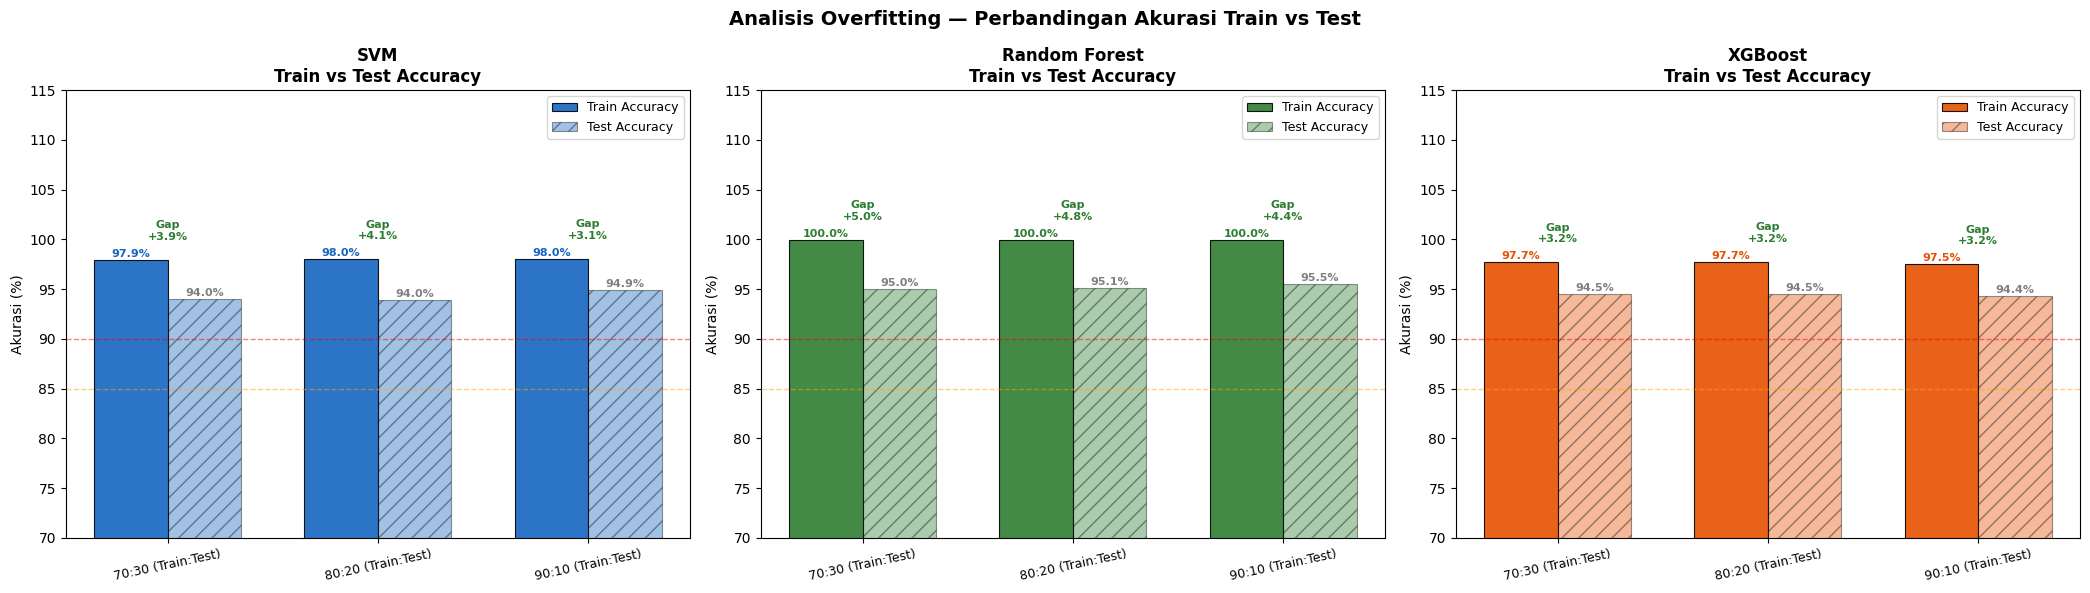

In [ ]:
# ── Visualisasi Train vs Test Accuracy per model per split ────────────
model_names_list = ['SVM', 'Random Forest', 'XGBoost']
split_labels     = [s['label'] for s in splits]
colors3          = ['#1565C0', '#2E7D32', '#E65100']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for col_i, (model_name, color) in enumerate(zip(model_names_list, colors3)):
    model_data = [r for r in all_results if r['Model'] == model_name]

    train_accs = [r['Acc_Train'] * 100 for r in model_data]
    test_accs  = [r['Accuracy']  * 100 for r in model_data]
    gaps       = [r['Gap_Acc']   * 100 for r in model_data]

    x     = np.arange(len(split_labels))
    width = 0.35

    bars_tr = axes[col_i].bar(x - width/2, train_accs, width,
                               label='Train Accuracy',
                               color=color, alpha=0.9,
                               edgecolor='black', linewidth=0.8)
    bars_te = axes[col_i].bar(x + width/2, test_accs, width,
                               label='Test Accuracy',
                               color=color, alpha=0.4,
                               edgecolor='black', linewidth=0.8,
                               hatch='//')

    # Label nilai di atas bar
    for bar, val in zip(bars_tr, train_accs):
        axes[col_i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                          f'{val:.1f}%', ha='center', fontsize=8,
                          fontweight='bold', color=color)
    for bar, val in zip(bars_te, test_accs):
        axes[col_i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                          f'{val:.1f}%', ha='center', fontsize=8,
                          fontweight='bold', color='gray')

    # Anotasi gap
    for xi, gap in zip(x, gaps):
        clr = '#C62828' if abs(gap) > 5 else '#2E7D32'
        axes[col_i].annotate(f'Gap\n{gap:+.1f}%',
                              xy=(xi, max(train_accs[x.tolist().index(xi)],
                                         test_accs[x.tolist().index(xi)]) + 2),
                              ha='center', fontsize=8, color=clr, fontweight='bold')

    axes[col_i].set_xticks(x)
    axes[col_i].set_xticklabels(split_labels, rotation=12, fontsize=9)
    axes[col_i].set_ylim(70, 115)
    axes[col_i].set_title(f'{model_name}\nTrain vs Test Accuracy',
                           fontsize=12, fontweight='bold')
    axes[col_i].set_ylabel('Akurasi (%)')
    axes[col_i].legend(fontsize=9)
    axes[col_i].axhline(y=90, color='red',    linestyle='--', linewidth=1, alpha=0.5)
    axes[col_i].axhline(y=85, color='orange', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Analisis Overfitting — Perbandingan Akurasi Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

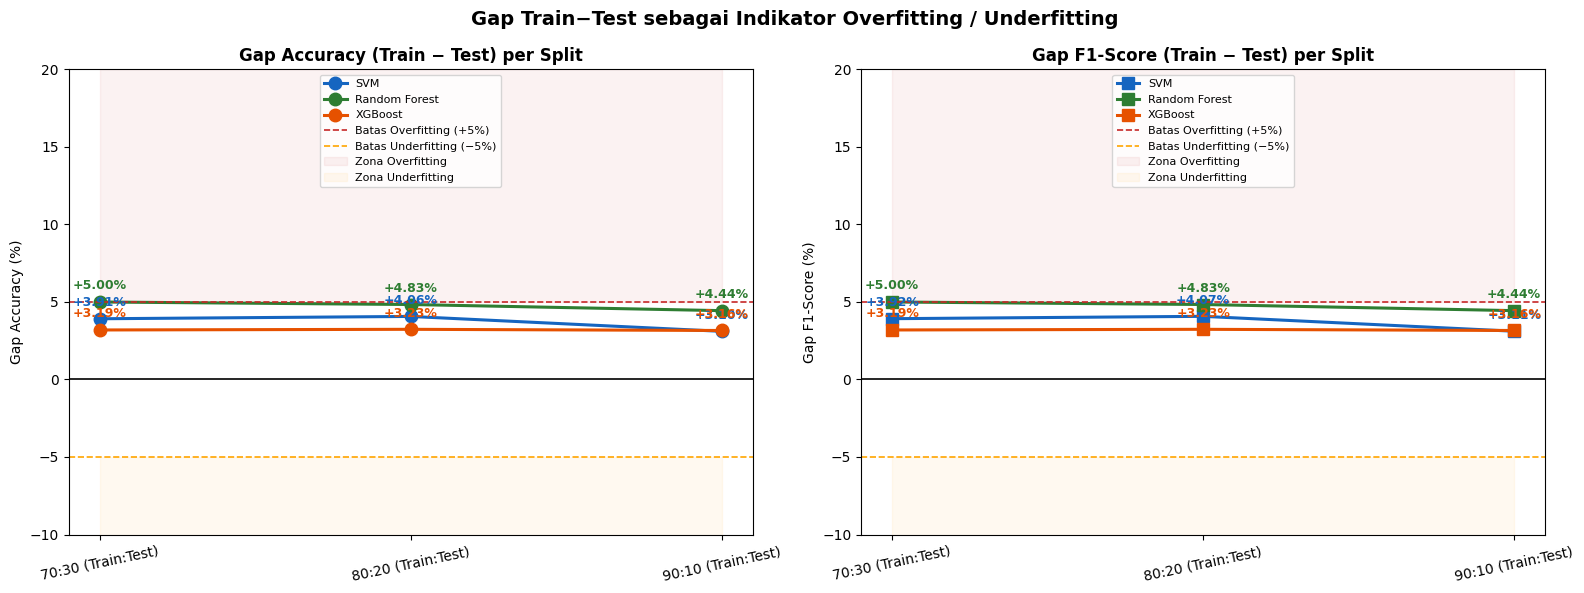

In [ ]:
# ── Grafik Gap (Train - Test) per model ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Subplot 1: Gap Accuracy ──────────────────────────────────────────
for model_name, color in zip(model_names_list, colors3):
    model_data = [r for r in all_results if r['Model'] == model_name]
    gaps = [r['Gap_Acc'] * 100 for r in model_data]
    axes[0].plot(split_labels, gaps, marker='o', linewidth=2.2,
                  markersize=9, label=model_name, color=color)
    for xi, gap in zip(split_labels, gaps):
        axes[0].annotate(f'{gap:+.2f}%', (xi, gap),
                          textcoords='offset points', xytext=(0, 9),
                          ha='center', fontsize=9, color=color, fontweight='bold')

axes[0].axhline(y=0,    color='black', linewidth=1.2, linestyle='-')
axes[0].axhline(y=5,    color='#C62828', linewidth=1.2, linestyle='--',
                 label='Batas Overfitting (+5%)')
axes[0].axhline(y=-5,   color='orange',  linewidth=1.2, linestyle='--',
                 label='Batas Underfitting (−5%)')
axes[0].fill_between(split_labels, 5, 20,
                      color='#C62828', alpha=0.06, label='Zona Overfitting')
axes[0].fill_between(split_labels, -20, -5,
                      color='orange',  alpha=0.06, label='Zona Underfitting')
axes[0].set_title('Gap Accuracy (Train − Test) per Split',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gap Accuracy (%)')
axes[0].set_ylim(-10, 20)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=12)

# ── Subplot 2: Gap F1-Score ──────────────────────────────────────────
for model_name, color in zip(model_names_list, colors3):
    model_data = [r for r in all_results if r['Model'] == model_name]
    gaps_f1 = [r['Gap_F1'] * 100 for r in model_data]
    axes[1].plot(split_labels, gaps_f1, marker='s', linewidth=2.2,
                  markersize=9, label=model_name, color=color)
    for xi, gap in zip(split_labels, gaps_f1):
        axes[1].annotate(f'{gap:+.2f}%', (xi, gap),
                          textcoords='offset points', xytext=(0, 9),
                          ha='center', fontsize=9, color=color, fontweight='bold')

axes[1].axhline(y=0,  color='black',   linewidth=1.2, linestyle='-')
axes[1].axhline(y=5,  color='#C62828', linewidth=1.2, linestyle='--',
                 label='Batas Overfitting (+5%)')
axes[1].axhline(y=-5, color='orange',  linewidth=1.2, linestyle='--',
                 label='Batas Underfitting (−5%)')
axes[1].fill_between(split_labels, 5, 20,
                      color='#C62828', alpha=0.06, label='Zona Overfitting')
axes[1].fill_between(split_labels, -20, -5,
                      color='orange',  alpha=0.06, label='Zona Underfitting')
axes[1].set_title('Gap F1-Score (Train − Test) per Split',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Gap F1-Score (%)')
axes[1].set_ylim(-10, 20)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=12)

plt.suptitle('Gap Train−Test sebagai Indikator Overfitting / Underfitting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Kesimpulan otomatis deteksi overfitting ────────────────────────────
print('=' * 70)
print('KESIMPULAN ANALISIS OVERFITTING')
print('=' * 70)
print('  Kriteria: |Gap Accuracy| ≤ 5% → Normal')
print('            Gap > 5%            → Overfitting')
print('            Gap < -5%           → Underfitting')
print()

for model_name in ['SVM', 'Random Forest', 'XGBoost']:
    model_data = [r for r in all_results if r['Model'] == model_name]
    print(f'  📌 {model_name}')
    for r in model_data:
        gap    = r['Gap_Acc'] * 100
        status = '✅ Normal      ' if abs(gap) <= 5 else \
                 ('⚠️ Overfitting ' if gap > 5 else '⚠️ Underfitting')
        print(f'     {r["Split"]:22} | '
              f'Train: {r["Acc_Train"]*100:.2f}% | '
              f'Test: {r["Accuracy"]*100:.2f}% | '
              f'Gap: {gap:+.2f}% | {status}')
    print()

# Hitung rata-rata gap per model
print('  Rata-rata Gap per Model:')
for model_name in ['SVM', 'Random Forest', 'XGBoost']:
    model_data = [r for r in all_results if r['Model'] == model_name]
    avg_gap = np.mean([r['Gap_Acc'] * 100 for r in model_data])
    status  = '✅ Tidak Overfitting' if abs(avg_gap) <= 5 else \
              ('⚠️ Cenderung Overfitting' if avg_gap > 5 else '⚠️ Cenderung Underfitting')
    print(f'     {model_name:<16} : Rata-rata Gap = {avg_gap:+.2f}%  →  {status}')

KESIMPULAN ANALISIS OVERFITTING
  Kriteria: |Gap Accuracy| ≤ 5% → Normal
            Gap > 5%            → Overfitting
            Gap < -5%           → Underfitting

  📌 SVM
     70:30 (Train:Test)     | Train: 97.93% | Test: 94.02% | Gap: +3.91% | ✅ Normal      
     80:20 (Train:Test)     | Train: 98.02% | Test: 93.95% | Gap: +4.06% | ✅ Normal      
     90:10 (Train:Test)     | Train: 98.05% | Test: 94.95% | Gap: +3.10% | ✅ Normal      

  📌 Random Forest
     70:30 (Train:Test)     | Train: 99.97% | Test: 94.98% | Gap: +5.00% | ✅ Normal      
     80:20 (Train:Test)     | Train: 99.98% | Test: 95.14% | Gap: +4.83% | ✅ Normal      
     90:10 (Train:Test)     | Train: 99.98% | Test: 95.54% | Gap: +4.44% | ✅ Normal      

  📌 XGBoost
     70:30 (Train:Test)     | Train: 97.70% | Test: 94.51% | Gap: +3.19% | ✅ Normal      
     80:20 (Train:Test)     | Train: 97.73% | Test: 94.50% | Gap: +3.23% | ✅ Normal      
     90:10 (Train:Test)     | Train: 97.51% | Test: 94.35% | Gap: +3.16% 

---
## 8. Model Comparison
### 8.1 Tabel Perbandingan Lengkap

In [ ]:
results_df = pd.DataFrame([{
    'Model'    : r['Model'],
    'Split'    : r['Split'],
    'Accuracy' : round(r['Accuracy'], 4),
    'Precision': round(r['Precision'], 4),
    'Recall'   : round(r['Recall'], 4),
    'F1-Score' : round(r['F1-Score'], 4),
} for r in all_results])

display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%')

print('📊 TABEL PERBANDINGAN PERFORMA SEMUA MODEL')
print('=' * 90)
print(display_df.to_string(index=False))

📊 TABEL PERBANDINGAN PERFORMA SEMUA MODEL
        Model              Split Accuracy Precision Recall F1-Score
          SVM 70:30 (Train:Test)   94.02%    94.17% 94.02%   94.01%
Random Forest 70:30 (Train:Test)   94.98%    94.98% 94.98%   94.97%
      XGBoost 70:30 (Train:Test)   94.51%    94.52% 94.51%   94.51%
          SVM 80:20 (Train:Test)   93.95%    94.14% 93.95%   93.95%
Random Forest 80:20 (Train:Test)   95.14%    95.15% 95.14%   95.14%
      XGBoost 80:20 (Train:Test)   94.50%    94.50% 94.50%   94.50%
          SVM 90:10 (Train:Test)   94.95%    95.22% 94.95%   94.94%
Random Forest 90:10 (Train:Test)   95.54%    95.56% 95.54%   95.54%
      XGBoost 90:10 (Train:Test)   94.35%    94.35% 94.35%   94.35%


### 8.2 Grafik Perbandingan Akurasi

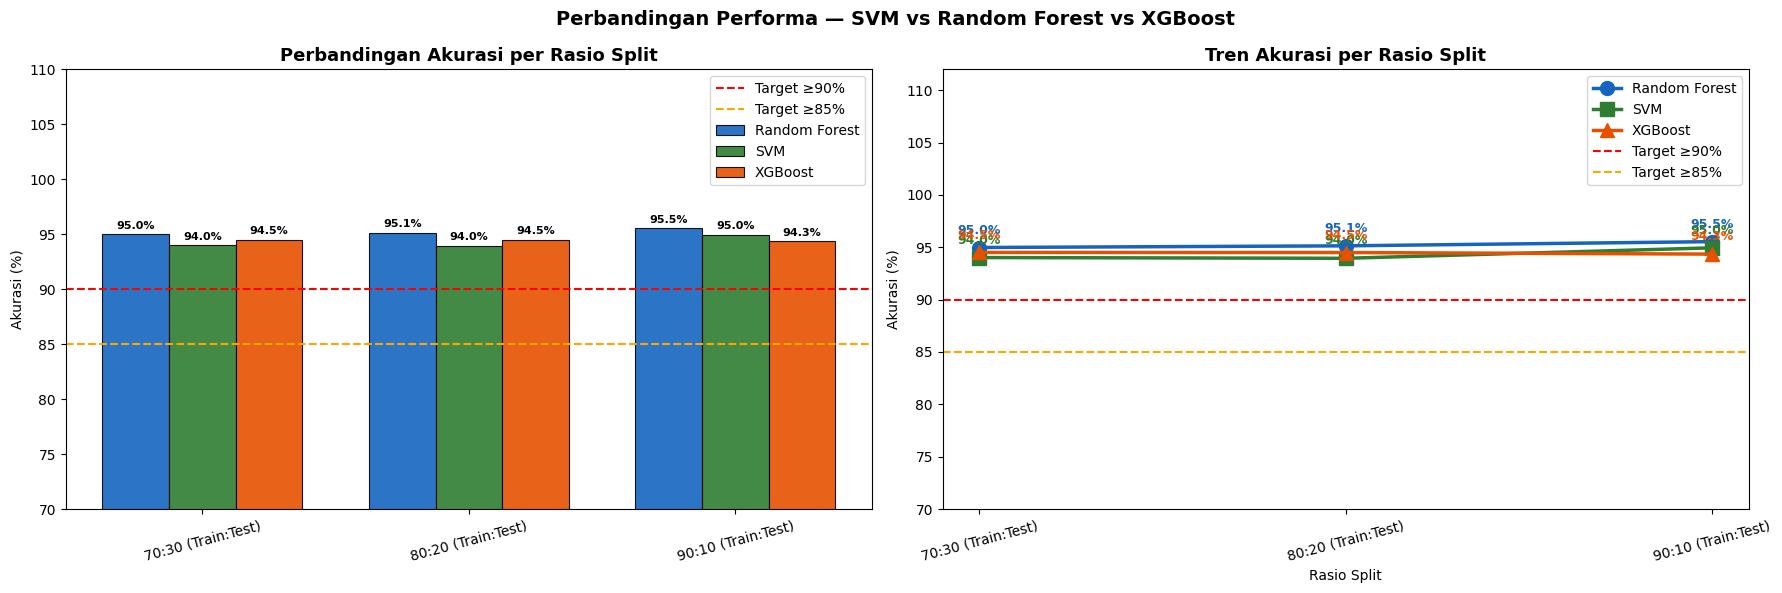

In [ ]:
pivot    = results_df.pivot(index='Split', columns='Model', values='Accuracy')
colors3  = ['#1565C0', '#2E7D32', '#E65100']
markers3 = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Bar Chart ────────────────────────────────────────────────
x     = np.arange(len(pivot.index))
width = 0.25
for i, (model, color) in enumerate(zip(pivot.columns, colors3)):
    bars = axes[0].bar(x + i*width, pivot[model]*100, width,
                       label=model, color=color, edgecolor='black',
                       linewidth=0.8, alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[0].axhline(y=90, color='red',    linestyle='--', linewidth=1.5, label='Target ≥90%')
axes[0].axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Target ≥85%')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(pivot.index, rotation=15)
axes[0].set_ylim(70, 110)
axes[0].set_title('Perbandingan Akurasi per Rasio Split', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Akurasi (%)')
axes[0].legend()

# ── Line Chart ───────────────────────────────────────────────
for model, color, marker in zip(pivot.columns, colors3, markers3):
    axes[1].plot(pivot.index, pivot[model]*100, color=color,
                 marker=marker, linewidth=2.5, markersize=10, label=model)
    for xi, yi in zip(pivot.index, pivot[model]*100):
        axes[1].annotate(f'{yi:.1f}%', (xi, yi),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, color=color, fontweight='bold')

axes[1].axhline(y=90, color='red',    linestyle='--', linewidth=1.5, label='Target ≥90%')
axes[1].axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Target ≥85%')
axes[1].set_ylim(70, 112)
axes[1].set_title('Tren Akurasi per Rasio Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_xlabel('Rasio Split')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Perbandingan Performa — SVM vs Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Perbandingan Semua Metrik Evaluasi

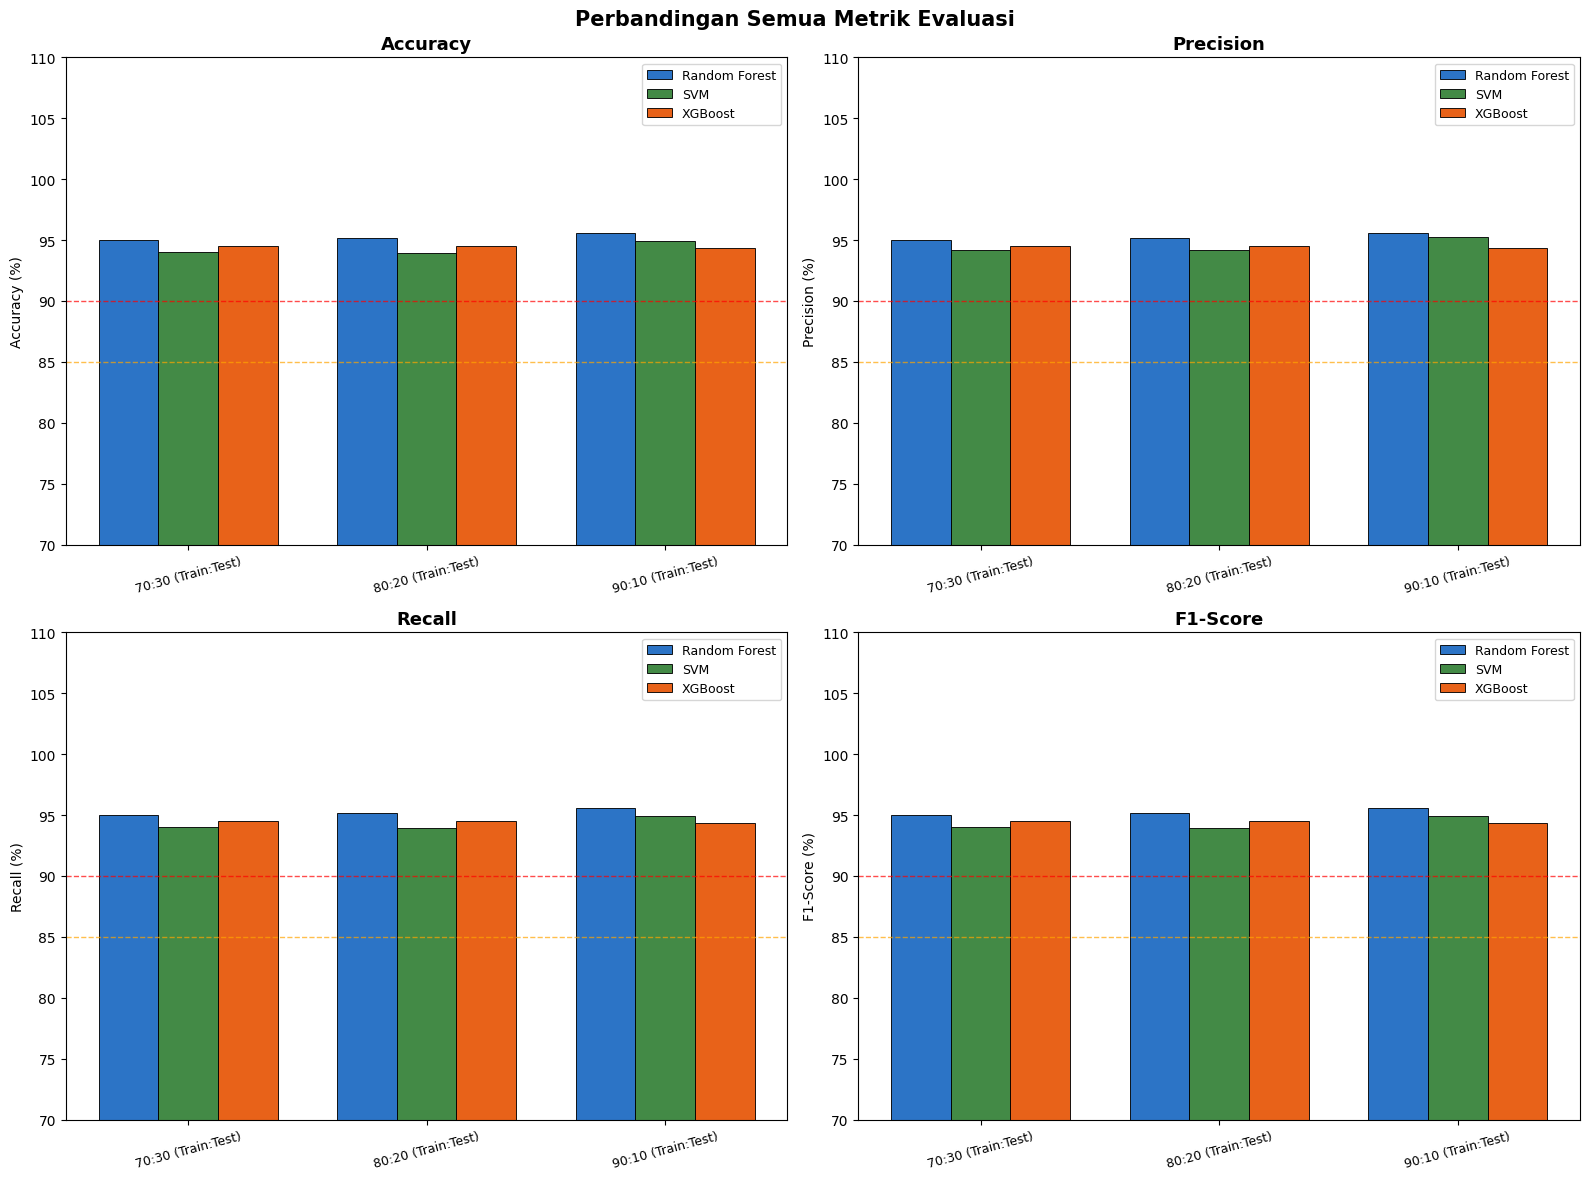

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    pivot_m = results_df.pivot(index='Split', columns='Model', values=metric)
    x = np.arange(len(pivot_m.index))
    for i, (model, color) in enumerate(zip(pivot_m.columns, colors3)):
        axes[idx].bar(x + i*0.25, pivot_m[model]*100, 0.25,
                      label=model, color=color,
                      edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[idx].set_xticks(x + 0.25)
    axes[idx].set_xticklabels(pivot_m.index, rotation=15, fontsize=9)
    axes[idx].set_ylim(70, 110)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric} (%)')
    axes[idx].legend(fontsize=9)
    axes[idx].axhline(y=90, color='red',    linestyle='--', linewidth=1, alpha=0.7)
    axes[idx].axhline(y=85, color='orange', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Perbandingan Semua Metrik Evaluasi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Feature Importance (RF & XGBoost)

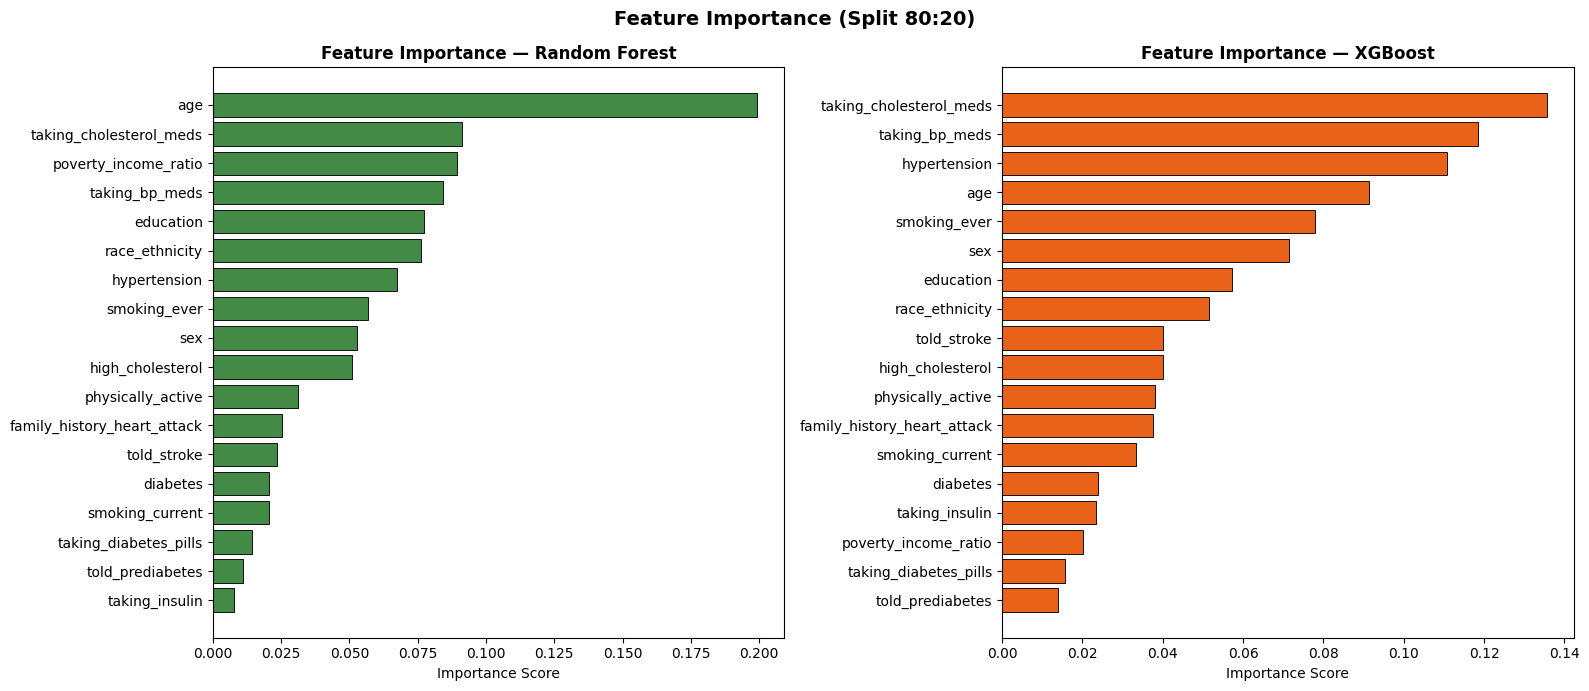

ℹ️  SVM menggunakan kernel 'rbf' — feature importance tidak tersedia secara langsung.


In [ ]:
res_8020_all  = [r for r in all_results if r['Split'] == '80:20 (Train:Test)']
feature_names = X.columns.tolist()

fi_models = [(r, color) for r, color in zip(res_8020_all, colors3)
             if r['Model'] in ['Random Forest', 'XGBoost']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, (res, color) in enumerate(fi_models):
    fi = pd.Series(res['model'].feature_importances_,
                   index=feature_names).sort_values(ascending=True)
    axes[i].barh(fi.index, fi.values, color=color,
                 edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[i].set_title(f'Feature Importance — {res["Model"]}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importance Score')

plt.suptitle('Feature Importance (Split 80:20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SVM linear: tampilkan koefisien
svm_res_8020 = [r for r in res_8020_all if r['Model'] == 'SVM'][0]
if svm_res_8020['model'].kernel == 'linear':
    coef = pd.Series(np.abs(svm_res_8020['model'].coef_[0]),
                     index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(coef.index, coef.values, color='#1565C0',
             edgecolor='black', alpha=0.9)
    plt.title('Feature Weight (|Koefisien|) — SVM Linear',
              fontsize=12, fontweight='bold')
    plt.xlabel('|Koefisien|')
    plt.tight_layout()
    plt.show()
else:
    print(f"ℹ️  SVM menggunakan kernel '{svm_res_8020['model'].kernel}' "
          "— feature importance tidak tersedia secara langsung.")

---
## 9. Ringkasan & Kesimpulan

In [ ]:
print('=' * 70)
print('VERIFIKASI TARGET AKURASI')
print('=' * 70)

for model_name in ['SVM', 'Random Forest', 'XGBoost']:
    model_res = [r for r in all_results if r['Model'] == model_name]
    accs  = [r['Accuracy'] for r in model_res]
    avg   = np.mean(accs)
    all90 = all(a >= 0.90 for a in accs)
    all85 = all(a >= 0.85 for a in accs)
    status = '✅ ≥90% di semua split' if all90 else \
             ('✅ ≥85% di semua split' if all85 else '⚠️  Ada split < 85%')
    print(f'\n  {model_name:15} : {status}')
    print(f'  {" ":15}   Akurasi : {[f"{a*100:.2f}%" for a in accs]}')
    print(f'  {" ":15}   Rata2   : {avg*100:.2f}%')

VERIFIKASI TARGET AKURASI

  SVM             : ✅ ≥90% di semua split
                    Akurasi : ['94.02%', '93.95%', '94.95%']
                    Rata2   : 94.30%

  Random Forest   : ✅ ≥90% di semua split
                    Akurasi : ['94.98%', '95.14%', '95.54%']
                    Rata2   : 95.22%

  XGBoost         : ✅ ≥90% di semua split
                    Akurasi : ['94.51%', '94.50%', '94.35%']
                    Rata2   : 94.45%


In [1]:
print('=' * 70)
print('KESIMPULAN AKHIR')
print('=' * 70)
print("""
1. DATA UNDERSTANDING
   Dataset Heart Disease Prediction dari Kaggle berisi 5.568 sampel
   dengan 18 fitur klinis dan 1 kolom target (heart_disease).
   Dataset bersifat TIDAK SEIMBANG: 90.54% negatif vs 9.46% positif.

2. PREPROCESSING
   - Tidak ditemukan missing values pada dataset ini.
   - Outlier pada fitur kontinu (age, poverty_income_ratio) ditangani
     dengan IQR Capping (Winsorization).
   - Data dinormalisasi dengan StandardScaler agar SVM optimal.
   - Ketidakseimbangan kelas diatasi dengan SMOTE sehingga distribusi
     kelas menjadi 50:50 dan model tidak bias ke kelas mayoritas.

3. EDA
   - Fitur seperti hypertension, family_history_heart_attack,
     taking_bp_meds, told_stroke, dan high_cholesterol paling
     berkorelasi dengan target heart_disease.
   - Dataset menjadi seimbang setelah SMOTE (5.041 tiap kelas).

4. HYPERPARAMETER TUNING
   - Ketiga algoritma di-tuning menggunakan GridSearchCV dengan
     Stratified 5-Fold Cross Validation.
   - Parameter terbaik setiap model dipilih otomatis berdasarkan
     skor akurasi tertinggi pada data validasi.

""")

KESIMPULAN AKHIR

1. DATA UNDERSTANDING
   Dataset Heart Disease Prediction dari Kaggle berisi 5.568 sampel
   dengan 18 fitur klinis dan 1 kolom target (heart_disease).
   Dataset bersifat TIDAK SEIMBANG: 90.54% negatif vs 9.46% positif.

2. PREPROCESSING
   - Tidak ditemukan missing values pada dataset ini.
   - Outlier pada fitur kontinu (age, poverty_income_ratio) ditangani
     dengan IQR Capping (Winsorization).
   - Data dinormalisasi dengan StandardScaler agar SVM optimal.
   - Ketidakseimbangan kelas diatasi dengan SMOTE sehingga distribusi
     kelas menjadi 50:50 dan model tidak bias ke kelas mayoritas.

3. EDA
   - Fitur seperti hypertension, family_history_heart_attack,
     taking_bp_meds, told_stroke, dan high_cholesterol paling
     berkorelasi dengan target heart_disease.
   - Dataset menjadi seimbang setelah SMOTE (5.041 tiap kelas).

4. HYPERPARAMETER TUNING
   - Ketiga algoritma di-tuning menggunakan GridSearchCV dengan
     Stratified 5-Fold Cross Validation.
   - 

---
## 10. Inference — Prediksi Data Pasien Baru

Bagian ini digunakan untuk memprediksi apakah seorang pasien baru berisiko
terkena penyakit jantung menggunakan **model terbaik** yang telah dilatih.

> ✅ **Section ini bersifat self-contained** — dapat dijalankan langsung
> tanpa harus menjalankan ulang seluruh sel sebelumnya, cukup jalankan
> **Cell 10.0 (Setup Inference)** terlebih dahulu, kemudian sel-sel di bawahnya.


### 10.0 Setup Inference (Self-Contained) — Jalankan Sel Ini Dulu!

> Sel ini akan **memuat ulang semua dependensi, dataset, dan melatih ulang
> model terbaik** secara otomatis sehingga inference bisa langsung dijalankan
> tanpa perlu menjalankan ulang sel-sel sebelumnya.


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   SETUP INFERENCE — SELF-CONTAINED                              ║
# ║   Jalankan sel ini sebelum inference, tidak perlu               ║
# ║   menjalankan ulang semua sel dari awal.                        ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

print('📦 Library berhasil diimport.')

# ── Load Dataset ──────────────────────────────────────────────────────
try:
    _ = df_clean
    print('✅ Dataset sudah tersedia dari sesi sebelumnya.')
except NameError:
    print('⬆️  Dataset belum dimuat. Silakan upload file CSV...')
    try:
        from google.colab import files
        uploaded = files.upload()
        df = pd.read_csv(list(uploaded.keys())[0])
    except Exception:
        # Fallback: baca dari path lokal jika ada
        df = pd.read_csv('heart_disease_prediction.csv')
    print(f'✅ Dataset dimuat: {df.shape[0]} baris × {df.shape[1]} kolom')

    # ── Preprocessing ulang ───────────────────────────────────────────
    continuous_cols = ['age', 'poverty_income_ratio']
    df_clean = df.copy()
    for col in continuous_cols:
        Q1    = df_clean[col].quantile(0.25)
        Q3    = df_clean[col].quantile(0.75)
        IQR   = Q3 - Q1
        df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    print('✅ Outlier capping selesai.')

# ── Fitur & Target ────────────────────────────────────────────────────
X = df_clean.drop('heart_disease', axis=1)
y = df_clean['heart_disease']

# ── Normalisasi ───────────────────────────────────────────────────────
try:
    _ = scaler
    print('✅ Scaler sudah tersedia dari sesi sebelumnya.')
    X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)
except NameError:
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    print('✅ Normalisasi StandardScaler selesai.')

# ── SMOTE ─────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# ── Split 80:20 (split terbaik) ───────────────────────────────────────
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_resampled, y_resampled,
    test_size=0.20, random_state=42, stratify=y_resampled
)

# ── Cek apakah model terbaik sudah ada dari sesi sebelumnya ──────────
_need_train = True
try:
    _ = model_terbaik
    print('✅ Model terbaik sudah tersedia dari sesi sebelumnya.')
    _need_train = False
except NameError:
    pass

if _need_train:
    print()
    print('🔄 Melatih ulang model terbaik (Random Forest, split 80:20)...')
    print('   (Proses ini hanya berjalan sekali saat file dibuka ulang)')

    # ── Hyperparameter terbaik Random Forest (hasil GridSearchCV) ─────
    # Nilai ini diambil dari hasil tuning GridSearchCV di notebook.
    # Parameter grid yang digunakan:
    #   n_estimators     : [100, 200, 300]
    #   max_depth        : [5, 10, 20, None]
    #   min_samples_split: [2, 5]
    #   min_samples_leaf : [1, 2]
    #   max_features     : ['sqrt', 'log2']
    #
    # ⚠️  PENTING: Sesuaikan nilai di bawah dengan best_rf_params
    #    yang muncul di output cell tuning Random Forest di notebook kamu.
    best_rf_params_inf = {
        'n_estimators'     : 300,
        'max_depth'        : None,
        'min_samples_split': 2,
        'min_samples_leaf' : 1,
        'max_features'     : 'sqrt',
    }

    model_terbaik = RandomForestClassifier(
        **best_rf_params_inf,
        random_state=42
    )
    model_terbaik.fit(X_train_best, y_train_best)

    acc = accuracy_score(y_test_best, model_terbaik.predict(X_test_best))
    f1  = f1_score(y_test_best, model_terbaik.predict(X_test_best), average='weighted')
    print(f'✅ Model Random Forest selesai dilatih.')
    print(f'   Akurasi (test 80:20) : {acc*100:.2f}%')
    print(f'   F1-Score (test 80:20): {f1*100:.2f}%')

# ── Simpan nama fitur & info model ────────────────────────────────────
feat_names      = X.columns.tolist()
NAMA_MODEL_BEST = 'Random Forest'
SPLIT_BEST      = '80:20 (Train:Test)'

print()
print('=' * 62)
print('  ✅ SETUP INFERENCE SELESAI')
print(f'  Model   : {NAMA_MODEL_BEST}')
print(f'  Split   : {SPLIT_BEST}')
print(f'  Fitur   : {len(feat_names)} fitur')
print('  Siap untuk inference pasien baru!')
print('=' * 62)

📦 Library berhasil diimport.
⬆️  Dataset belum dimuat. Silakan upload file CSV...


Saving heart_disease_prediction.csv to heart_disease_prediction.csv
✅ Dataset dimuat: 5568 baris × 19 kolom
✅ Outlier capping selesai.
✅ Normalisasi StandardScaler selesai.

🔄 Melatih ulang model terbaik (Random Forest, split 80:20)...
   (Proses ini hanya berjalan sekali saat file dibuka ulang)
✅ Model Random Forest selesai dilatih.
   Akurasi (test 80:20) : 95.14%
   F1-Score (test 80:20): 95.14%

  ✅ SETUP INFERENCE SELESAI
  Model   : Random Forest
  Split   : 80:20 (Train:Test)
  Fitur   : 18 fitur
  Siap untuk inference pasien baru!


### 10.1 Fungsi Inference (Model Terbaik: Random Forest)


In [ ]:
def predict_pasien(data_pasien: dict, tampilkan_detail: bool = True):
    """
    Memprediksi risiko penyakit jantung untuk satu pasien baru
    menggunakan model terbaik (XGBoost, split 80:20).

    Parameters
    ----------
    data_pasien      : dict — nilai tiap fitur pasien (18 fitur)
    tampilkan_detail : bool — jika True, cetak output lengkap

    Returns
    -------
    dict — hasil prediksi model terbaik
    """
    # ── 1. Buat DataFrame dari input ─────────────────────────────────
    df_input = pd.DataFrame([data_pasien], columns=feat_names)

    # ── 2. IQR Capping (sama seperti preprocessing training) ─────────
    df_input_clean = df_input.copy()
    for col in ['age', 'poverty_income_ratio']:
        if col in df_input_clean.columns:
            Q1    = df_clean[col].quantile(0.25)
            Q3    = df_clean[col].quantile(0.75)
            IQR   = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df_input_clean[col] = df_input_clean[col].clip(lower, upper)

    # ── 3. Normalisasi dengan scaler yang sudah di-fit ────────────────
    input_scaled = scaler.transform(df_input_clean)

    # ── 4. Prediksi dari model terbaik ────────────────────────────────
    pred = model_terbaik.predict(input_scaled)[0]
    prob = model_terbaik.predict_proba(input_scaled)[0]

    hasil = {
        'model'       : NAMA_MODEL_BEST,
        'prediksi'    : int(pred),
        'label'       : '🔴 BERISIKO SAKIT JANTUNG' if pred == 1 else '🟢 TIDAK BERISIKO',
        'prob_negatif': round(prob[0] * 100, 2),
        'prob_positif': round(prob[1] * 100, 2),
    }

    # ── 5. Tampilkan output ────────────────────────────────────────────
    if tampilkan_detail:
        print('=' * 62)
        print('  DATA INPUT PASIEN')
        print('=' * 62)
        for k, v in data_pasien.items():
            print(f'  {k:35} : {v}')

        print('\n' + '=' * 62)
        print(f'  HASIL PREDIKSI — {NAMA_MODEL_BEST} [{SPLIT_BEST}]')
        print('=' * 62)
        print(f'  Prediksi     : {hasil["label"]}')
        print(f'  Prob Tidak Sakit Jantung : {hasil["prob_negatif"]:>6.2f}%')
        print(f'  Prob Sakit Jantung       : {hasil["prob_positif"]:>6.2f}%')
        print('=' * 62)

    return hasil


print(f'✅ Fungsi predict_pasien() siap — menggunakan {NAMA_MODEL_BEST} [{SPLIT_BEST}].')


✅ Fungsi predict_pasien() siap — menggunakan Random Forest [80:20 (Train:Test)].


### 10.2 Contoh Inference — Pasien 1 (Profil Berisiko Tinggi)


In [ ]:
# ── Pasien 1: Laki-laki 65 thn, hipertensi, riwayat keluarga,
#              kolesterol tinggi, pernah stroke, tidak aktif fisik
pasien_1 = {
    'taking_bp_meds'             : 1,      # Minum obat tekanan darah
    'taking_cholesterol_meds'    : 1,      # Minum obat kolesterol
    'age'                        : 65.0,   # 65 tahun
    'sex'                        : 1.0,    # Laki-laki
    'race_ethnicity'             : 4.0,
    'education'                  : 2.0,
    'poverty_income_ratio'       : 1.2,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 1,      # Pernah prediabetes
    'told_stroke'                : 1,      # Pernah stroke
    'family_history_heart_attack': 1,      # Ada riwayat keluarga
    'diabetes'                   : 0,
    'smoking_ever'               : 1,      # Pernah merokok
    'smoking_current'            : 0,
    'physically_active'          : 0,      # Tidak aktif fisik
    'hypertension'               : 1,      # Hipertensi
    'high_cholesterol'           : 1,      # Kolesterol tinggi
}

hasil_p1 = predict_pasien(pasien_1)

  DATA INPUT PASIEN
  taking_bp_meds                      : 1
  taking_cholesterol_meds             : 1
  age                                 : 65.0
  sex                                 : 1.0
  race_ethnicity                      : 4.0
  education                           : 2.0
  poverty_income_ratio                : 1.2
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 1
  told_stroke                         : 1
  family_history_heart_attack         : 1
  diabetes                            : 0
  smoking_ever                        : 1
  smoking_current                     : 0
  physically_active                   : 0
  hypertension                        : 1
  high_cholesterol                    : 1

  HASIL PREDIKSI — Random Forest [80:20 (Train:Test)]
  Prediksi     : 🔴 BERISIKO SAKIT JANTUNG
  Prob Tidak Sakit Jantung :  24.33%
  Prob Sakit Jantung       :  75.67%


### 10.3 Contoh Inference — Pasien 2 (Profil Risiko Rendah)


In [ ]:
# ── Pasien 2: Perempuan 30 thn, sehat, aktif fisik, tidak ada faktor risiko
pasien_2 = {
    'taking_bp_meds'             : 0,
    'taking_cholesterol_meds'    : 0,
    'age'                        : 30.0,
    'sex'                        : 2.0,    # Perempuan
    'race_ethnicity'             : 6.0,
    'education'                  : 5.0,    # Pendidikan tinggi
    'poverty_income_ratio'       : 4.5,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 0,
    'told_stroke'                : 0,
    'family_history_heart_attack': 0,
    'diabetes'                   : 0,
    'smoking_ever'               : 0,
    'smoking_current'            : 0,
    'physically_active'          : 1,      # Aktif fisik
    'hypertension'               : 0,
    'high_cholesterol'           : 0,
}

hasil_p2 = predict_pasien(pasien_2)

  DATA INPUT PASIEN
  taking_bp_meds                      : 0
  taking_cholesterol_meds             : 0
  age                                 : 30.0
  sex                                 : 2.0
  race_ethnicity                      : 6.0
  education                           : 5.0
  poverty_income_ratio                : 4.5
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 0
  told_stroke                         : 0
  family_history_heart_attack         : 0
  diabetes                            : 0
  smoking_ever                        : 0
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 0

  HASIL PREDIKSI — Random Forest [80:20 (Train:Test)]
  Prediksi     : 🟢 TIDAK BERISIKO
  Prob Tidak Sakit Jantung : 100.00%
  Prob Sakit Jantung       :   0.00%


### 10.4 Visualisasi Probabilitas Hasil Inference


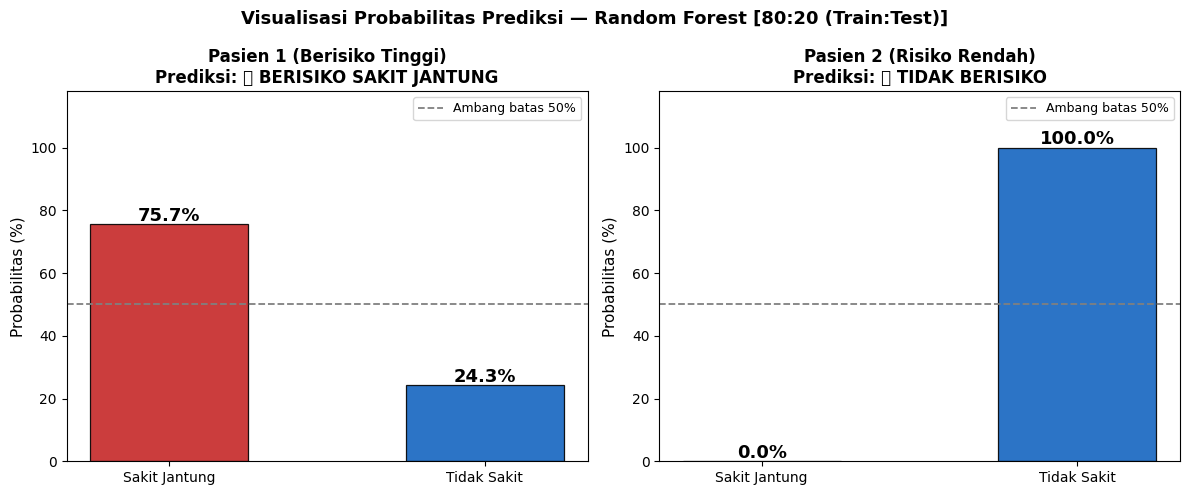

In [ ]:
# ── Visualisasi probabilitas model terbaik untuk kedua pasien ─────────
pasien_labels = ['Pasien 1 (Berisiko Tinggi)', 'Pasien 2 (Risiko Rendah)']
hasil_list    = [hasil_p1, hasil_p2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col_i, (hasil, label_p) in enumerate(zip(hasil_list, pasien_labels)):
    prob_values = [hasil['prob_positif'], hasil['prob_negatif']]
    bar_labels  = ['Sakit Jantung', 'Tidak Sakit']
    bar_colors  = ['#C62828', '#1565C0']

    bars = axes[col_i].bar(bar_labels, prob_values,
                            color=bar_colors, edgecolor='black',
                            linewidth=0.9, alpha=0.9, width=0.5)
    for bar, val in zip(bars, prob_values):
        axes[col_i].text(bar.get_x() + bar.get_width()/2,
                          bar.get_height() + 1.0,
                          f'{val:.1f}%', ha='center',
                          fontsize=13, fontweight='bold')

    axes[col_i].axhline(y=50, color='gray', linestyle='--',
                         linewidth=1.3, label='Ambang batas 50%')
    axes[col_i].set_ylim(0, 118)
    axes[col_i].set_ylabel('Probabilitas (%)', fontsize=11)
    axes[col_i].set_title(
        f'{label_p}\n'
        f'Prediksi: {hasil["label"]}',
        fontsize=12, fontweight='bold'
    )
    axes[col_i].legend(fontsize=9)

plt.suptitle(f'Visualisasi Probabilitas Prediksi — {NAMA_MODEL_BEST} [{SPLIT_BEST}]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 10.7 Template Input Pasien Baru

Gunakan template di bawah untuk memasukkan data pasien baru.  
Cukup ubah nilai yang bertanda `← ganti`, lalu jalankan cell.

| Fitur | Tipe | Keterangan |
|---|---|---|
| taking_bp_meds | 0 / 1 | Minum obat tekanan darah |
| taking_cholesterol_meds | 0 / 1 | Minum obat kolesterol |
| age | float | Usia dalam tahun |
| sex | 1.0 / 2.0 | 1=Laki-laki, 2=Perempuan |
| race_ethnicity | 1.0–6.0 | Kode etnis |
| education | 1.0–5.0 | 1=rendah, 5=tinggi |
| poverty_income_ratio | float | Rasio pendapatan (misal 2.5) |
| taking_insulin | 0 / 1 | Pakai insulin |
| taking_diabetes_pills | 0 / 1 | Minum obat diabetes |
| told_prediabetes | 0 / 1 | Pernah didiagnosis prediabetes |
| told_stroke | 0 / 1 | Pernah stroke |
| family_history_heart_attack | 0 / 1 | Riwayat keluarga |
| diabetes | 0 / 1 | Punya diabetes |
| smoking_ever | 0 / 1 | Pernah merokok |
| smoking_current | 0 / 1 | Merokok saat ini |
| physically_active | 0 / 1 | Aktif fisik |
| hypertension | 0 / 1 | Hipertensi |
| high_cholesterol | 0 / 1 | Kolesterol tinggi |


In [ ]:
# ============================================================
#  TEMPLATE — Isi nilai sesuai kondisi pasien baru
#  Ganti nilai di bawah lalu jalankan cell ini
# ============================================================
pasien_baru = {
    'taking_bp_meds'             : 1,      # ← ganti: 0 atau 1
    'taking_cholesterol_meds'    : 1,      # ← ganti: 0 atau 1
    'age'                        : 19.0,   # ← ganti: usia (tahun)
    'sex'                        : 2.0,    # ← ganti: 1.0=Laki-laki, 2.0=Perempuan
    'race_ethnicity'             : 7.0,    # ← ganti: 1.0–6.0
    'education'                  : 4.0,    # ← ganti: 1.0–5.0
    'poverty_income_ratio'       : 2.5,    # ← ganti: angka desimal
    'taking_insulin'             : 1,      # ← ganti: 0 atau 1
    'taking_diabetes_pills'      : 0,      # ← ganti: 0 atau 1
    'told_prediabetes'           : 1,      # ← ganti: 0 atau 1
    'told_stroke'                : 0,      # ← ganti: 0 atau 1
    'family_history_heart_attack': 1,      # ← ganti: 0 atau 1
    'diabetes'                   : 0,      # ← ganti: 0 atau 1
    'smoking_ever'               : 1,      # ← ganti: 0 atau 1
    'smoking_current'            : 0,      # ← ganti: 0 atau 1
    'physically_active'          : 1,      # ← ganti: 0 atau 1
    'hypertension'               : 0,      # ← ganti: 0 atau 1
    'high_cholesterol'           : 1,      # ← ganti: 0 atau 1
}

# Jalankan prediksi dengan model terbaik (XGBoost, split 80:20)
_ = predict_pasien(pasien_baru)


  DATA INPUT PASIEN
  taking_bp_meds                      : 1
  taking_cholesterol_meds             : 1
  age                                 : 19.0
  sex                                 : 2.0
  race_ethnicity                      : 7.0
  education                           : 4.0
  poverty_income_ratio                : 2.5
  taking_insulin                      : 1
  taking_diabetes_pills               : 0
  told_prediabetes                    : 1
  told_stroke                         : 0
  family_history_heart_attack         : 1
  diabetes                            : 0
  smoking_ever                        : 1
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 1

  HASIL PREDIKSI — Random Forest [80:20 (Train:Test)]
  Prediksi     : 🟢 TIDAK BERISIKO
  Prob Tidak Sakit Jantung :  67.33%
  Prob Sakit Jantung       :  32.67%
